In [1]:
import json 
import pandas as pd 
import seaborn as sns 
import numpy as np
import glob
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from matplotlib.markers import MarkerStyle
from matplotlib.patches import Ellipse
import scipy.stats
from sklearn import metrics
import pickle
import sys

from config import llm_review_path, supp_table_path, figure_path_2, figure_path, home_path

sys.path.insert(1, home_path) 
from common_functions import entropy, mean_confidence_interval, format_p, read_fasta, sort_dict_by_value

/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
SAVE_FIGS = False

In [3]:
def save_figure(fig, name, root_path = figure_path, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")
        
def pickle_obj(obj, fn):
    with open(fn, "wb") as f:
        pickle.dump(obj, f)
    f.close()
    
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']

def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df


In [4]:
def p_val_to_stars(p):
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return "ns"

In [5]:
protein_gym = pd.read_csv(llm_review_path + "data/ProteinGym_reference_file_substitutions.csv")

corr_df = pd.read_csv(
    home_path + "singh/nlp_review/notebooks/final_notebooks/all_masked_model_DMS_correlation.csv",
    index_col = 0 
)

with open(home_path + "singh/nlp_review/notebooks/final_notebooks/representative_experiments.pkl", "rb") as f1:
    representative_experiments = pickle.load(f1)
f1.close()

model_info = pd.read_csv("model_info.txt", delimiter = "\t")
display_names = dict(zip(model_info["model_string"], model_info["display_name"]))

model_to_color = {}
for m in set(display_names.keys()):
    if m in ["esm_1_UR100", "protbert"]:
        model_to_color[m] = "dodgerblue"
    elif m == "esm-1v":
        model_to_color[m] = "mediumseagreen"
    elif m == "protbert_bfd":
        model_to_color[m] = "orange"
    else:
        model_to_color[m] = "tomato"
    
print(display_names)

{'esm_1_43M_UR50S': 'ESM-1 (UR50S  43M) ', 'esm_1_85M_UR50S': 'ESM-1 (UR50S  85M) ', 'esm_1b': 'ESM-1b', 'esm_1_UR100': 'ESM-1 (UR100  670M)', 'esm_1_UR50D': 'ESM-1 (UR50D  670M)', 'esm_1_UR50S': 'ESM-1 (UR50S  670M)', 'esm_1v': 'ESM-1v', 'esm_2': 'ESM2 (3B)', 'esm_2_150M': 'ESM2 (150M)', 'esm_2_15B': 'ESM2 (15B)', 'esm_2_35M': 'ESM2 (35M)', 'esm_2_650M': 'ESM2 (650M)', 'esm_2_8M': 'ESM2 (8M)', 'protbert': 'ProtBERT', 'protbert_bfd': 'ProtBERT BFD'}


In [6]:
use_preload = True 

if use_preload:
    with open("all_dms_id_aligned_hsps.pkl", "rb") as f:
        all_hsp_dfs = pickle.load(f)
    f.close() 
else:
    
    pg_aln_base = home_path + "singh/nlp_review/alignment_experiments/blastp_sandbox/"

    alignment_paths = [
        pg_aln_base + "protein_gym_large_searches_BFD/",   
        pg_aln_base + "protein_gym_large_searches/",
        pg_aln_base + "protein_gym_large_searches_UR100/",
        pg_aln_base + "protein_gym_large_searches_UR90/"    
    ]

    names = ["BFD", "UR50", "UR100", "UR90"]
    
    all_hsp_dfs = {}

    for name, pg_path in zip(names, alignment_paths):
        
        print(name)
        
        
        dataset_dfs = {} 
        
        # bfd is split into multiple sections, must deal with partitions 
        if name == "BFD":
            unique_experiments = glob.glob(pg_path + "*_20.json")
            unique_experiments = list(
                map(
                    lambda x : x.replace(pg_path, "").replace("_e_val_200_BFD_split_20.json", ""),
                    unique_experiments
                )
            )
            
            for dms_id in unique_experiments:
                
                reference_seq = protein_gym.loc[protein_gym["DMS_id"] == dms_id].iloc[0]["target_seq"]
                
                json_files = glob.glob(pg_path + dms_id + "*.json")
                
                all_hsps = []
                for jfn in json_files:
                    with open(jfn, "r") as f2:
                        data = json.load(f2)
                    f2.close()
                    query = data["BlastOutput2"][0]
                    hits = query["report"]["results"]["search"]["hits"]
                    qlen = query["report"]["results"]["search"]["query_len"]
                    for hit in hits:
                        hsps = hit["hsps"]
                        for hsp in hsps:
                            all_hsps.append(hsp)
            
                hsp_df = pd.DataFrame(all_hsps)
                hsp_df["percent_identity"] = hsp_df["identity"] / (hsp_df["align_len"] - hsp_df["gaps"])
                hsp_df["percent_gaps"] = hsp_df["gaps"] / hsp_df["align_len"] 
                hsp_df["alignment_frac"] = hsp_df["align_len"] / qlen

                dataset_dfs[dms_id] = hsp_df
            
            all_hsp_dfs[name] = dataset_dfs

        else:
            
            pg_files = glob.glob(pg_path + "*.json")
            
            for pgf in pg_files:
                try:
                    with open(pgf, "r") as f2:
                        data = json.load(f2)
                    f2.close()
                except:
                    continue

                dms_id = pgf.replace(pg_path, "").replace(f"_e_val_200_{name}.json", "")

                reference_seq = protein_gym.loc[protein_gym["DMS_id"] == dms_id].iloc[0]["target_seq"]

                query = data["BlastOutput2"][0]
                hits = query["report"]["results"]["search"]["hits"]
                qlen = query["report"]["results"]["search"]["query_len"]

                all_hsps = []
                for hit in hits:
                    hsps = hit["hsps"]
                    for hsp in hsps:
                        all_hsps.append(hsp)

                hsp_df = pd.DataFrame(all_hsps)
                hsp_df["percent_identity"] = hsp_df["identity"] / (hsp_df["align_len"] - hsp_df["gaps"])
                hsp_df["percent_gaps"] = hsp_df["gaps"] / hsp_df["align_len"] 

                hsp_df["alignment_frac"] = hsp_df["align_len"] / qlen

                dataset_dfs[dms_id] = hsp_df

            all_hsp_dfs[name] = dataset_dfs
    
    with open("all_dms_id_aligned_hsps.pkl", "wb") as f:
        pickle.dump(all_hsp_dfs, f)
    f.close()

In [7]:
PCT_IDENT = 0.0
GAP_PCT = 0.75
ALN_FRAC = 0.75 

HQ_CUTOFF = 0.4 

homolog_tracker = {}

hq_experiments = []
for index, row in corr_df.iterrows():
    if np.max(row.values) > HQ_CUTOFF:
        hq_experiments.append(index)




green_1 = "#357847"
coral_1 = "#E39695"
dark_blue_1 = "#2B2D42"
dark_red_1 = "#A3320B"
light_blue_1 = "#0C7489"
orange_1 = "#f5a60a"

ur_50_color = dark_red_1
ur_90_color = "seagreen"
ur_100_color = "dodgerblue"


# UniRef50 Homologs vs DMS Performance 

In [8]:
corr_results_UR50 = {}

exp_to_homologs = {}

db_dfs = all_hsp_dfs["UR50"]

for k, dfc in db_dfs.items():
   
    dfc_2 = dfc.loc[
        (dfc["percent_identity"] >= PCT_IDENT) & 
        (dfc["alignment_frac"] >= ALN_FRAC) & 
        (dfc["percent_gaps"] <= GAP_PCT) &
        (dfc["evalue"] < 1e-5)
    ]
    
    if k in representative_experiments and k in hq_experiments:
        exp_to_homologs[k] = len(dfc_2)

homolog_tracker["UR50"] = exp_to_homologs

In [9]:

esm2_models = [
    "esm_2_8M", 
    "esm_2_35M", 
    "esm_2_150M" , 
    "esm_2_650M", 
    "esm_2", 
    "esm_2_15B"
]

esm_1_ur50 = [
    'esm_1_UR50D',
    'esm_1_43M_UR50S', 
    'esm_1_85M_UR50S', 
    'esm_1_UR50S',
    'esm_1b',
]

ur50_models = esm2_models + esm_1_ur50 
ur100_models = ["esm_1_UR100", "protbert"]
other_models = ["esm_1v"]


for i, m in enumerate(ur50_models + ur100_models + other_models):
    
    x = []
    y = []

    for k2, v2 in exp_to_homologs.items():
        corr_vals = corr_df.loc[k2]
        x.append(v2)
        y.append(corr_vals[m])

    corr, p = scipy.stats.spearmanr(x, y)
    corr_results_UR50[m] = {"corr" : corr, "p" : p}

corr_results_UR50

{'esm_2_8M': {'corr': 0.3351105896649016, 'p': 0.018586467280947566},
 'esm_2_35M': {'corr': 0.518992831618663, 'p': 0.00013306756828506948},
 'esm_2_150M': {'corr': 0.5374116688398918, 'p': 6.843039123763724e-05},
 'esm_2_650M': {'corr': 0.42506186396137263, 'p': 0.0023311612144060155},
 'esm_2': {'corr': 0.34271282441826195, 'p': 0.01592806670523256},
 'esm_2_15B': {'corr': 0.3310798745943281, 'p': 0.020142212944969415},
 'esm_1_UR50D': {'corr': 0.497665756941451, 'p': 0.00027444904375110464},
 'esm_1_43M_UR50S': {'corr': 0.5809842089698897, 'p': 1.2040678913346475e-05},
 'esm_1_85M_UR50S': {'corr': 0.6274139648461169, 'p': 1.4037945560799023e-06},
 'esm_1_UR50S': {'corr': 0.5058802522118605, 'p': 0.00020884083134708442},
 'esm_1b': {'corr': 0.4534299345846499, 'p': 0.0010681359966015502},
 'esm_1_UR100': {'corr': 0.21668920132564512, 'p': 0.13478412198326897},
 'protbert': {'corr': 0.16633077379835248, 'p': 0.2533556629616363},
 'esm_1v': {'corr': 0.47511416123014066, 'p': 0.0005613

# UniRef100 Homologs vs DMS Performance 

In [10]:
exp_to_homologs = {}

corr_results_UR100 = {}

db_dfs = all_hsp_dfs["UR100"]

for k, dfc in db_dfs.items():
    dfc_2 = dfc.loc[
        (dfc["percent_identity"] >= PCT_IDENT) & 
        (dfc["alignment_frac"] >= ALN_FRAC) & 
        (dfc["percent_gaps"] <= GAP_PCT) &
        (dfc["evalue"] < 1e-5)
    ]
    
    if k in representative_experiments and k in hq_experiments:
        exp_to_homologs[k] = len(dfc_2)
homolog_tracker["UR100"] = exp_to_homologs

In [11]:

for i, m in enumerate(ur50_models + ur100_models + other_models):
    
    x = []
    y = []

    for k2, v2 in exp_to_homologs.items():
        corr_vals = corr_df.loc[k2]
        x.append(v2)
        y.append(corr_vals[m])

    corr, p = scipy.stats.spearmanr(x, y)
    corr_results_UR100[m] = {"corr" : corr, "p" : p}

corr_results_UR100

{'esm_2_8M': {'corr': -0.13765306122448978, 'p': 0.3455802220734343},
 'esm_2_35M': {'corr': -0.0004081632653061224, 'p': 0.9977791845986661},
 'esm_2_150M': {'corr': -0.09775510204081632, 'p': 0.5039906682352778},
 'esm_2_650M': {'corr': -0.17663265306122447, 'p': 0.22471594366043404},
 'esm_2': {'corr': -0.1223469387755102, 'p': 0.4023270776001615},
 'esm_2_15B': {'corr': -0.06612244897959184, 'p': 0.6516991680384925},
 'esm_1_UR50D': {'corr': -0.06928571428571427, 'p': 0.6361783870058384},
 'esm_1_43M_UR50S': {'corr': 0.05499999999999999, 'p': 0.7074035691077121},
 'esm_1_85M_UR50S': {'corr': 0.08346938775510203, 'p': 0.568542898590928},
 'esm_1_UR50S': {'corr': -0.06653061224489795, 'p': 0.6496880820590378},
 'esm_1b': {'corr': -0.11295918367346938, 'p': 0.43965259893819486},
 'esm_1_UR100': {'corr': 0.3028571428571428, 'p': 0.03441052372029922},
 'protbert': {'corr': 0.17877551020408164, 'p': 0.2190519736949154},
 'esm_1v': {'corr': 0.04877551020408162, 'p': 0.7392756834706125}}

# UniRef90 Homologs vs DMS Performance 

In [12]:
exp_to_homologs = {}
corr_results_UR90 = {}
db_dfs = all_hsp_dfs["UR90"]


for k, dfc in db_dfs.items():
    dfc_2 = dfc.loc[
        (dfc["percent_identity"] >= PCT_IDENT) & 
        (dfc["alignment_frac"] >= ALN_FRAC) & 
        (dfc["percent_gaps"] <= GAP_PCT) &
        (dfc["evalue"] < 1e-5)
    ]
    
    if k in representative_experiments and k in hq_experiments:
        exp_to_homologs[k] = len(dfc_2)
        
homolog_tracker["UR90"] = exp_to_homologs



In [13]:
for i, m in enumerate(ur50_models + ur100_models + other_models):
    
    x = []
    y = []

    for k2, v2 in exp_to_homologs.items():
        corr_vals = corr_df.loc[k2]
        x.append(v2)
        y.append(corr_vals[m])

    corr, p = scipy.stats.spearmanr(x, y)
    corr_results_UR90[m] = {"corr" : corr, "p" : p}

corr_results_UR90

{'esm_2_8M': {'corr': 0.15857547391572996, 'p': 0.27647305720020027},
 'esm_2_35M': {'corr': 0.3251613562628529, 'p': 0.022624915521283182},
 'esm_2_150M': {'corr': 0.27322125573318334, 'p': 0.05749973247856952},
 'esm_2_650M': {'corr': 0.15342228123056625, 'p': 0.2925801403068222},
 'esm_2': {'corr': 0.12097247382696127, 'p': 0.40767395864484657},
 'esm_2_15B': {'corr': 0.10117605044237209, 'p': 0.48910857186954204},
 'esm_1_UR50D': {'corr': 0.33194724366014766, 'p': 0.019798460817677152},
 'esm_1_43M_UR50S': {'corr': 0.3825607797362108, 'p': 0.006670937800834336},
 'esm_1_85M_UR50S': {'corr': 0.3944998598186692, 'p': 0.0050322764395170725},
 'esm_1_UR50S': {'corr': 0.3443965408401471, 'p': 0.01538522492523143},
 'esm_1b': {'corr': 0.3021505651637557, 'p': 0.03485419279687157},
 'esm_1_UR100': {'corr': 0.23628153787121792, 'p': 0.10215190366142393},
 'protbert': {'corr': 0.19658664768253134, 'p': 0.17578890738544609},
 'esm_1v': {'corr': 0.39939794395506234, 'p': 0.004469419698168966}

In [14]:
# making tables 

display_names_a = {
    "protbert" : "ProtBERT", 
    "esm_1_43M_UR50S" : "ESM-1 (43M)",
    "esm_1_85M_UR50S" : "ESM-1 (85M)",
    "esm_1_UR50S" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1b" : "ESM-1b",
    "esm_1v" : "ESM-1v",
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" :"ESM-2 (35M)",
    "esm_2_150M" :"ESM-2 (150M)",
    "esm_2_650M" :"ESM-2 (650M)",
    "esm_2" :"ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}



table_a = []

dataset_results = [corr_results_UR50, corr_results_UR90, corr_results_UR100]
dataset_labels = ["UniRef50", "UniRef90", "UniRef100"]

for dsr, dsl in zip(dataset_results,dataset_labels):
    for k, v in dsr.items():
        if k in display_names_a.keys():
            table_a.append([display_names_a[k], "DMS", dsl, v["corr"], v["p"]])
            
table_a = pd.DataFrame(table_a, columns = ["Model", "Task", "Dataset", "Spearman Correlation", "Spearman p-value"])
table_a.to_csv(supp_table_path + "homologs_v_performance_all_models_all_datasets_DMS.csv", index = False)

table_b = pd.DataFrame(homolog_tracker)
table_b = table_b.rename(columns = {"UR50" : "UniRef50", "UR90" : "UniRef90", "UR100" : "UniRef100"})
# changing order 
table_b["Task"] = "DMS"
table_b = table_b[["Task", "UniRef50", "UniRef90", "UniRef100"]]
table_b.index.name = 'Identifier'

table_b.to_csv(supp_table_path  + "homologs_all_datasets_DMS.csv", index = True)

table_c = corr_df.loc[corr_df.index.isin(list(table_b.index))]
table_c = table_c.rename(columns = display_names_a)
table_c_rows = []
for index, row in table_c.iterrows():
    for c in display_names_a.values():
        table_c_rows.append([index, "DMS", c, row[c]])
        
table_c = pd.DataFrame(table_c_rows, columns = ["Identifier", "Task", "Model", "Performance"]) 
table_c.to_csv(supp_table_path  + "all_model_performance_DMS.csv", index = False)


In [15]:
table_a

,Model,Task,Dataset,Spearman Correlation,Spearman p-value
0,ESM-2 (8M),DMS,UniRef50,0.335111,0.018586
1,ESM-2 (35M),DMS,UniRef50,0.518993,0.000133
2,ESM-2 (150M),DMS,UniRef50,0.537412,0.000068
3,ESM-2 (650M),DMS,UniRef50,0.425062,0.002331
4,ESM-2 (3B),DMS,UniRef50,0.342713,0.015928
5,ESM-2 (15B),DMS,UniRef50,0.331080,0.020142
6,ESM-1 (670M) UR50D,DMS,UniRef50,0.497666,0.000274
7,ESM-1 (43M),DMS,UniRef50,0.580984,0.000012
8,ESM-1 (85M),DMS,UniRef50,0.627414,0.000001
9,ESM-1 (670M) UR50S,DMS,UniRef50,0.505880,0.000209


In [16]:
import copy

def plot_ci_manual(t, s_err, n, x, x2, y2, ax=None):
    """Return an axes of confidence bands using a simple approach.
    
    Notes
    -----
    .. math:: \left| \: \hat{\mu}_{y|x0} - \mu_{y|x0} \: \right| \; \leq \; T_{n-2}^{.975} \; \hat{\sigma} \; \sqrt{\frac{1}{n}+\frac{(x_0-\bar{x})^2}{\sum_{i=1}^n{(x_i-\bar{x})^2}}}
    .. math:: \hat{\sigma} = \sqrt{\sum_{i=1}^n{\frac{(y_i-\hat{y})^2}{n-2}}}
    
    References
    ----------
    .. [1] M. Duarte.  "Curve fitting," Jupyter Notebook.
       http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/CurveFitting.ipynb
    
    """
    if ax is None:
        ax = plt.gca()
    
    ci = t * s_err * np.sqrt(1/n + (x2 - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    ax.fill_between(x2, y2 + ci, y2 - ci, color="gray", alpha = 0.2, edgecolor=None)

    return ax, x2, y2 + ci, y2 - ci

def polyval_equation(a, b):
    """Return a 1D polynomial."""
    return np.polyval(a, b) 

-------------------
UR50 UR100
[2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0]
2 min_y 1
2 min_y 2
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
0.8225806451612903
11 3
[[19, 4], [3, 11]]
chi sq 0.0008658338712252277
fisher 0.0004141581875011175
-------------------
UR50 UR90
[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0]
0 min_y 1
0 min_y 2
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
0.6605351170568562
12 1
[[10, 9], [1, 12]]
chi sq 0.024461573152328442
fisher 0.010883771823765537
-------------------
UR90 UR100
[4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0]
4 min_y 1
4 min_y 2
[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
0.8307692307692308
6 2
[[23, 1], [2, 6]]
chi sq 0.0002128294190143768
fisher 0.0002020288449654412


/tmp/ipykernel_125232/3856035561.py:200: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1["corr_diff"] = corr_df[m2] - corr_df[m1]
/tmp/ipykernel_125232/3856035561.py:233: UserWarning: FixedFormatter should only be used together with FixedLocator
  auroc_ax.set_xticklabels(auroc_ax.get_xticklabels(), fontweight = "bold")
/tmp/ipykernel_125232/3856035561.py:234: UserWarning: FixedFormatter should only be used together with FixedLocator
  auroc_ax.set_yticklabels(auroc_ax.get_yticklabels(), fontweight = "bold")
/tmp/ipykernel_125232/3856035561.py:200: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

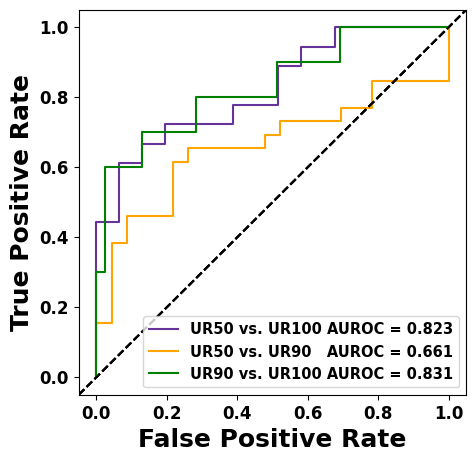

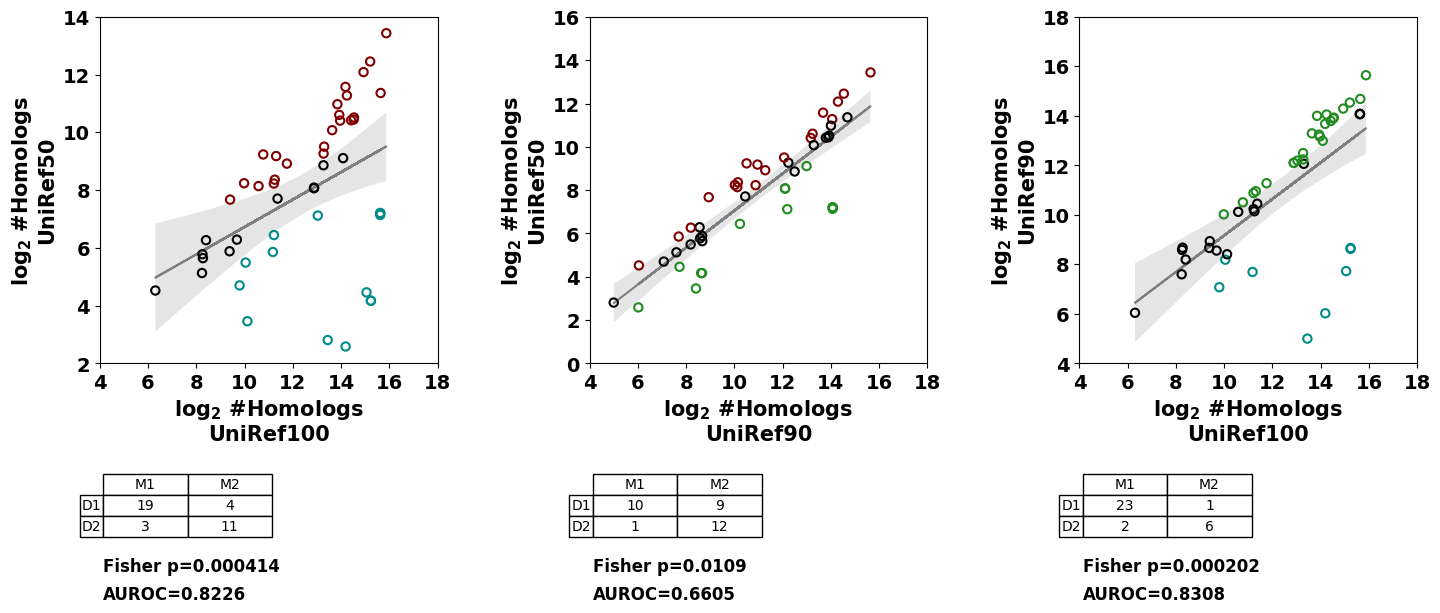

In [17]:

auroc_fig, auroc_ax = plt.subplots(figsize = (5,5))

fig, axes = plt.subplots(1,3, figsize = (17,4.5))
fig.subplots_adjust(wspace = 0.45)


groups = [
    ["UR50", "UR100"], 
    ["UR50", "UR90"],
    ["UR90", "UR100"]
]

group_to_name = {
    "UR50" : "UniRef50",
    "UR90" : "UniRef90",
    "UR100" : "UniRef100"
}

group_to_model = [
    ["esm_1_UR50S", "esm_1_UR100"],
    ["esm_1b", "esm_1v"],
    ["esm_1v", "esm_1_UR100"],
]

# group_to_model = {
#     "UR50" : "esm_1_UR50S",
#     "UR100" : "esm_1_UR100",
#     "UR90" : "esm_1v"
# }

group_to_color = {
    "UR50" : "maroon",
    "UR100" : "darkcyan", 
    "UR90" : "forestgreen"
}

group_to_summary = {}

auroc_colors = ["rebeccapurple", "orange", "green"]

for ax_i, group in enumerate(groups):
    print("-------------------")
    print(group[0], group[1])
    ax = axes[ax_i]

    ds1, ds2 = group

    homs_ds1 = homolog_tracker[ds1]
    homs_ds2 = homolog_tracker[ds2]


    ### modified from answer here 
    #   https://stackoverflow.com/questions/27164114/show-confidence-limits-and-prediction-limits-in-scatter-plot

    x = []
    y = []
    colors = []
    for k,v in homs_ds1.items():

        r1 = np.log2(v)
        r2 = np.log2(homs_ds2[k])
        
        

        y.append(r1)
        x.append(r2)

    x = np.asarray(x)
    y = np.asarray(y)
    # x = heights
    # y = weights

    p, cov = np.polyfit(x, y, 1, cov=True)                     # parameters and covariance from of the fit of 1-D polynom.
    y_model = polyval_equation(p, x)                                   # model using the fit parameters; NOTE: parameters here are coefficients

    # Statistics
    n = x.size                                           # number of observations
    m = p.size                                                 # number of parameters
    dof = n - m                                                # degrees of freedom
    t = scipy.stats.t.ppf(0.975, n - m)                              # t-statistic; used for CI and PI bands

    # Estimates of Error in Data/Model
    resid = y - y_model                                        # residuals; diff. actual data from predicted values
    chi2 = np.sum((resid / y_model)**2)                        # chi-squared; estimates error in data
    chi2_red = chi2 / dof                                      # reduced chi-squared; measures goodness of fit
    s_err = np.sqrt(np.sum(resid**2) / dof)                    # standard deviation of the error

    # Data


    # Fit
    ax.plot(x, y_model, "-", color="0.1", linewidth=1.5, alpha=0.5, label="Fit")  

    x2 = np.linspace(np.min(x), np.max(x), 100)
    y2 = polyval_equation(p, x2)

    # Confidence Interval (select one)
    ax, x2, y2_ci_u, y2_ci_l = plot_ci_manual(t, s_err, n, x, x2, y2, ax=ax)


    below_ci_experiments = []
    above_ci_experiments = []

    x3 = []
    y3 = []
    colors = []
    k_tracker = []

    for k, v in homs_ds1.items():
        k_tracker.append(k)
        r1 = np.log2(v)
        r2 = np.log2(homs_ds2[k])
        
        x3.append(r2)
        y3.append(r1)

        x_val = round(r2, 2)
        y_val = round(r1, 2)


        closest_estimated_x_val_pos = np.argmin(np.abs(copy.deepcopy(x2) - x_val))
        y_low = y2_ci_l[closest_estimated_x_val_pos]
        y_high = y2_ci_u[closest_estimated_x_val_pos]

        if y_val < y_low:
            colors.append(group_to_color[ds2])
            below_ci_experiments.append(k)
        elif y_val > y_high:
            colors.append(group_to_color[ds1])
            above_ci_experiments.append(k)
        else:
            colors.append("black")
            
    
            
    dfg = pd.DataFrame.from_dict({"x" : x3, "y" : y3, "color" : colors, "exp" : k_tracker}).set_index("exp")
    
    m1 = group_to_model[ax_i][0]
    m2 = group_to_model[ax_i][1]
    
    m1_performance = corr_df[m1].to_dict()
    m2_performance = corr_df[m2].to_dict()
    
    dfg["m1"] = m1_performance
    dfg["m2"] = m2_performance
    
    group_to_summary["_".join(group)] = dfg

    ax.scatter(x3,y3,color = colors, marker=MarkerStyle("o", fillstyle = "none"))
    
    current_x = list(ax.get_xticks())
    min_x = int(np.min(current_x))
    max_x = int(np.max(current_x))
    if min_x % 2 != 0:
        min_x -= 1
        
    if max_x % 2 != 0:
        max_x += 1
    
    new_x = list(range(min_x, max_x+1))
    new_x = new_x[::2]
    ax.set_xticks(new_x)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight = "bold")
    
    
    current_y = list(ax.get_yticks())
    print(current_y)
    min_y = int(np.min(current_y))
    max_y = int(np.max(current_y))
    print(min_y, "min_y 1")
    
    if min_y % 2 != 0:
        min_y -= 1
        
    print(min_y, "min_y 2")
        
    if max_y % 2 != 0:
        max_y += 1
    
    new_y = list(range(min_y, max_y+1))
    print(new_y)
    new_y = new_y[::2]
    ax.set_yticks(new_y)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight = "bold")

    ax.set_ylabel(r"$\mathbf{log_2}$ #Homologs" + f"\n{group_to_name[ds1]}", fontsize = 15, fontweight = "bold")
    ax.set_xlabel(r"$\mathbf{log_2}$ #Homologs" + f"\n{group_to_name[ds2]}", fontsize = 15, fontweight = "bold")
   
#     if ax_i == 0:
        

#         e1 = Ellipse((0.74, 0.23), height = 0.3, width= 0.2, angle = 135, linestyle = "--", facecolor = "none", edgecolor = "black", transform = ax.transAxes)
#         ax.add_patch(e1, )


    m1 = group_to_model[ax_i][0]
    m2 = group_to_model[ax_i][1]

    v1 = corr_df[[m2,m1]]
    v1["corr_diff"] = corr_df[m2] - corr_df[m1]
    
    corr_diff_labels = []
    hom_diff_predictors = []
    for index, row in v1.iterrows():
        if index in homs_ds1.keys():
            c_diff_label = 1 if row["corr_diff"] > 0 else 0 
#             hom_diff = np.log(homs_ds1[index]) - np.log(homs_ds2[index])
            
            hom_diff = np.log2(homs_ds1[index]) - np.log2(homs_ds2[index])
            corr_diff_labels.append(c_diff_label)
            hom_diff_predictors.append(abs(hom_diff))
            
    max_val = np.max(hom_diff_predictors)
    hom_diff_predictors = np.asarray(hom_diff_predictors) / max_val

            
    fpr, tpr, thresholds = metrics.roc_curve(corr_diff_labels, hom_diff_predictors, pos_label=1)
    auroc = metrics.auc(fpr, tpr)
    
    ## adding space to make it line up better 
    if group[1] == "UR90":
        
        auroc_label = group[0] + " vs. " + group[1] + "   AUROC = " + str(round(auroc, 3))
    else:
        auroc_label = group[0] + " vs. " + group[1] + " AUROC = " + str(round(auroc, 3))
        
    auroc_ax.plot(fpr, tpr, color = auroc_colors[ax_i], label = auroc_label)
    auroc_ax.set_xlabel("False Positive Rate", fontsize = 18, fontweight = "bold")
    auroc_ax.set_ylabel("True Positive Rate", fontsize = 18, fontweight = "bold")
    auroc_ax.plot([0,1],[0,1], linestyle = "--", color = "black", transform=auroc_ax.transAxes)
    auroc_ax.legend(loc = "lower right", prop = {"weight" : "bold", "size" : 10.5})
    
    auroc_ax.set_xticklabels(auroc_ax.get_xticklabels(), fontweight = "bold")
    auroc_ax.set_yticklabels(auroc_ax.get_yticklabels(), fontweight = "bold")
    
    auroc = metrics.auc(fpr, tpr)
    print(auroc)

    c1 = 0
    i1 = 0 

    for index, row in corr_df.iterrows():
        if index in below_ci_experiments:
            val_1 = row[m2]
            val_2 = row[m1]

            if val_1 > val_2:
                c1 += 1
            else:
                i1 += 1
    #             print(index)

    print(c1, i1)

    c2 = 0
    i2 = 0 

    for index, row in corr_df.iterrows():
        if index in above_ci_experiments:
            val_1 = row[m2]
            val_2 = row[m1]

            if val_1 <= val_2:
                c2 += 1
            else:
                i2 += 1


    confusion_matrix = [[c2, i2], [i1, c1]]


    print(confusion_matrix)
    # print(precision, recall, (tp + tn) / (tp + fp + tn + fn))
    p = scipy.stats.chi2_contingency(confusion_matrix)[1]
    px = scipy.stats.fisher_exact(confusion_matrix)[1]
    print("chi sq", p)
    print("fisher", px)
    
    ax.table(
        confusion_matrix, 
        cellLoc = 'center', 
        rowLoc = 'center', 
        loc='bottom', 
        bbox=[0.01, -0.5, 0.5, 0.18],
        rowLabels = ["D1", "D2"],
        colLabels = ["M1", "M2"]
    )

    ax.text(0.01, -0.6, "Fisher p=" + format_p(px), transform = ax.transAxes, fontsize = 12, fontweight = "bold")
    ax.text(0.01, -0.68, "AUROC=" + str(round(auroc, 4)), transform = ax.transAxes, fontsize = 12, fontweight = "bold")

# SAVE_FIGS = True

auroc_ax.set_xticklabels(auroc_ax.get_xticklabels(), fontsize = 12)
auroc_ax.set_yticklabels(auroc_ax.get_yticklabels(), fontsize = 12)

# if SAVE_FIGS:
#     save_figure(fig, "homologs_between_datasets_three_panel")
#     save_figure(auroc_fig, "auroc_dataset_homologs_as_predictor")
    
# # SAVE_FIGS = False

# # save_figure(fig, "homologs_between_datasets_three_panel")
# # save_figure(auroc_fig, "auroc_dataset_homologs_as_predictor")

save_figure(fig, "homologs_between_datasets_three_panel", root_path = figure_path_2)
save_figure(auroc_fig, "auroc_dataset_homologs_as_predictor", root_path = figure_path_2)


In [18]:

groups = ["UR50_UR100", "UR50_UR90", "UR90_UR100"]

y_vals = []
p_vals = []

dfg = group_to_summary[groups[0]]
dfg["hom_diff"] = dfg["x"] - dfg['y']
dfg["performance_diff"] = dfg["m2"] - dfg["m1"]
corr, p = scipy.stats.spearmanr(dfg["hom_diff"], dfg["performance_diff"])

y_vals.append(corr)
p_vals.append(p)


dfg = group_to_summary[groups[1]]
dfg["hom_diff"] = dfg["x"] - dfg['y']
dfg["performance_diff"] = dfg["m2"] - dfg["m1"]
corr, p = scipy.stats.spearmanr(dfg["hom_diff"], dfg["performance_diff"])

y_vals.append(corr)
p_vals.append(p)


dfg = group_to_summary[groups[2]]
dfg["hom_diff"] = dfg["x"] - dfg['y']
dfg["performance_diff"] = dfg["m2"] - dfg["m1"]
corr, p = scipy.stats.spearmanr(dfg["hom_diff"], dfg["performance_diff"])

y_vals.append(corr)
p_vals.append(p)


/tmp/ipykernel_125232/3497279992.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([""])
/tmp/ipykernel_125232/3497279992.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13,  fontweight = "bold")


[Text(0, 0.0, '0.0'),
 Text(0, 0.1, '0.1'),
 Text(0, 0.2, '0.2'),
 Text(0, 0.30000000000000004, '0.3'),
 Text(0, 0.4, '0.4'),
 Text(0, 0.5, '0.5')]

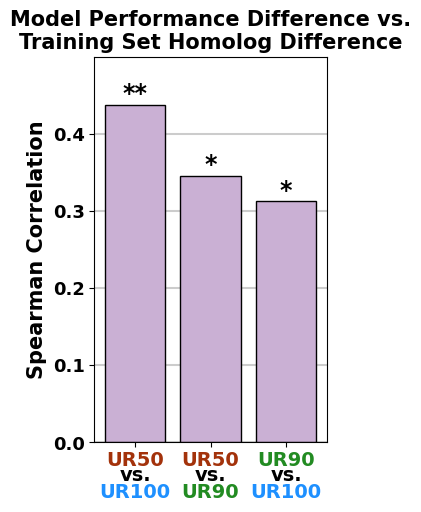

In [19]:
fig,ax = plt.subplots(figsize = (3,5))

ax.bar(
    [0,1,2], 
    y_vals,
    color = "#cab0d4",
    edgecolor = "black",
)

str_to_color_1 = {
    "UR50" : ur_50_color,
    "UR90" : "forestgreen",
    "UR100" : ur_100_color
}

ax.set_ylabel(r"Spearman Correlation", fontsize = 15, fontweight = "bold")

ax.set_title("Model Performance Difference vs.\nTraining Set Homolog Difference", fontsize = 15,  fontweight = "bold")
ax.set_ylim(top=0.499)

ax.set_xticklabels([""])
for i in range(0,3):
    ax.text(i, y_vals[i] + 0.005, p_val_to_stars(p_vals[i]), fontsize = 17, horizontalalignment = "center",  fontweight = "bold")
    
    ds1 = groups[i].split("_")[0]
    ds2 = groups[i].split("_")[1]
    
    
    ax.text(
        i,
        -0.03,
        ds1, 
        horizontalalignment = "center",
        fontsize = 14, 
        color = str_to_color_1[ds1],
        fontweight = "bold"
    )
    
    ax.text(
        i,
        -0.05,
        "vs.", 
        horizontalalignment = "center",
        fontsize = 14, 
        fontweight = "bold"
    )
    
    ax.text(
        i,
        -0.072,
        ds2, 
        horizontalalignment = "center",
        fontsize = 14, 
        color = str_to_color_1[ds2],
        fontweight = "bold"
    )
    
    
    
for i in ax.get_yticks():
    ax.axhline(y = i, color = 'black', alpha = 0.2, zorder = 0)
    
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13,  fontweight = "bold")


In [20]:
y_vals, p_vals

([0.4371428571428571, 0.34571428571428564, 0.3123469387755102],
 [0.0016856172542459985, 0.014971440011532494, 0.02889070731035927])

In [21]:
homolog_tracker_df = pd.DataFrame(homolog_tracker)
homolog_tracker_df

,UR50,UR100,UR90
NRAM_I33A0_Jiang_standard_2016,22,34055,212
P53_HUMAN_Kotler_2018,78,823,377
RL401_YEAST_Roscoe_2013,603,1753,1456
RASH_HUMAN_Bandaru_2017,5613,37842,23783
ENV_HV1B9_DuenasDecamp_2016,147,50516,17254
PTEN_HUMAN_Mighell_2018,329,2441,1133
A0A2Z5U3Z0_9INFA_Wu_2014,18,38660,405
YAP1_HUMAN_Araya_2012,45,1057,292
CP2C9_HUMAN_Amorosi_activity_2021,11076,60111,51174
UBC9_HUMAN_Weile_2017,3053,18613,13099


In [22]:
homolog_tracker_df.to_csv("homolog_tracker_ProtienGym.csv")

1.1485229530179918e-12


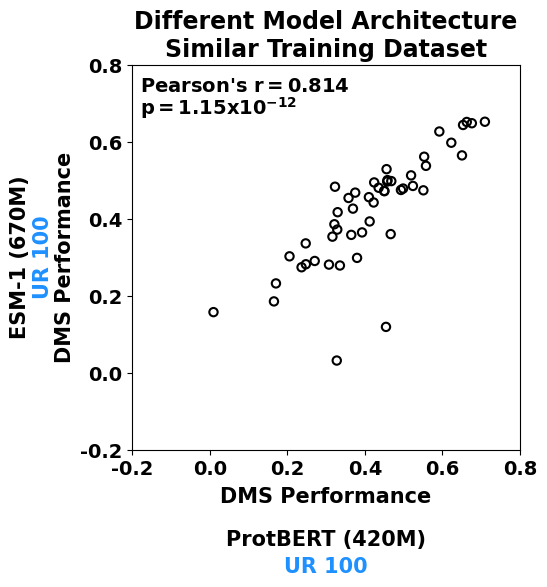

In [23]:
fig, ax = plt.subplots(figsize = (5, 5))
# fig.subplots_adjust(wspace = 0.5)


corr_sub_df = corr_df.loc[
    (corr_df.index.isin(representative_experiments)) &
    (corr_df.index.isin(hq_experiments))
]


x1 = corr_sub_df["protbert"]
x2 = corr_sub_df["esm_1_UR100"]

corr, p = scipy.stats.pearsonr(x1,x2)
print(p)
ax.scatter(x1,x2, color = "black", alpha = 1, marker=MarkerStyle("o", fillstyle = "none"))

x3 = np.linspace(-0.2, 0.8, 100)

# ax.plot(x3, x3, linestyle = "--", color = "black", zorder = 1, alpha = 0.3)


ticks = [-0.2,0.0,0.2, 0.4,0.6,0.8]
tick_labels = [-0.2, 0.0, 0.2, 0.4,0.6,0.8]

ax.set_yticks(ticks)
ax.set_xticks(ticks)
ax.set_yticklabels(tick_labels, fontsize = 14,fontweight = "bold")
ax.set_xticklabels(tick_labels, fontsize = 14,fontweight = "bold")
ax.set_ylim(bottom = -0.2, top = 0.8)
ax.set_xlim(left = -0.2, right = 0.8)

ax.text(0.02, 0.93, r"Pearson's $\mathbf{r = " + str(round(corr, 3)) + "}$", fontsize = 14,fontweight = "bold",transform = ax.transAxes, horizontalalignment = "left")
ax.text(0.02, 0.87, r"$\mathbf{p = " + format_p(p) + "}$", fontsize = 14,transform = ax.transAxes,fontweight = "bold", horizontalalignment = "left")

ax.set_xlabel("DMS Performance\n", fontsize = 15, labelpad = 6, fontweight = "bold")
ax.text(
    0.5, 
    -0.25, 
    "ProtBERT (420M)", 
    horizontalalignment = "center",  
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)

ax.text(
    0.5, 
    -0.32, 
    "UR 100", 
    horizontalalignment = "center", 
    color = "dodgerblue", 
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)

ax.set_ylabel("DMS Performance", fontsize = 15,fontweight = "bold")

ax.text(
    -0.29, 
    0.5, 
    "ESM-1 (670M)", 
    rotation = 90, 
    verticalalignment = "center", 
    horizontalalignment = "center",  
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)


ax.text(
    -0.23, 
    0.5, 
    "UR 100", 
    rotation = 90, 
    verticalalignment = "center", 
    horizontalalignment = "center", 
    color = "dodgerblue", 
    fontsize = 15, 
    transform = ax.transAxes,
    fontweight = "bold"
)


ax.set_title("Different Model Architecture\nSimilar Training Dataset", fontsize = 17,fontweight = "bold")

# if SAVE_FIGS:
#     save_figure(fig, "same_dataset_different_model")

save_figure(fig, "DMS_correlation_esm_1_protbert", root_path = figure_path_2)



0.12485246158702372


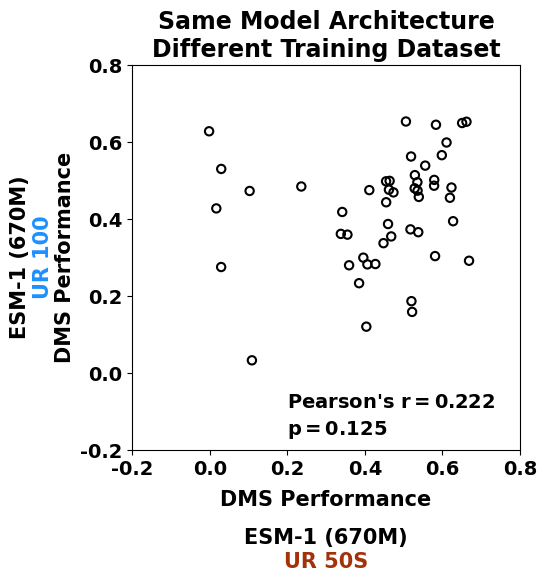

In [24]:
fig, ax = plt.subplots(figsize = (5, 5))
# fig.subplots_adjust(wspace = 0.5)


corr_sub_df = corr_df.loc[
    (corr_df.index.isin(representative_experiments)) &
    (corr_df.index.isin(hq_experiments))
]


x1 = corr_sub_df["esm_1_UR50D"]
x2 = corr_sub_df["esm_1_UR100"]

corr, p = scipy.stats.pearsonr(x1,x2)
print(p)
ax.scatter(x1,x2, color = "black", alpha = 1, marker=MarkerStyle("o", fillstyle = "none"))

ticks = [-0.2,0.0,0.2, 0.4,0.6,0.8]
tick_labels = [-0.2, 0.0, 0.2, 0.4,0.6,0.8]

# ax.plot(x3, x3, linestyle = "--", color = "black", zorder = 1, alpha = 0.3)


ticks = [-0.2,0.0,0.2, 0.4,0.6,0.8]
tick_labels = [-0.2, 0.0, 0.2, 0.4,0.6,0.8]

ax.set_yticks(ticks)
ax.set_xticks(ticks)
ax.set_yticklabels(tick_labels, fontsize = 14,fontweight = "bold")
ax.set_xticklabels(tick_labels, fontsize = 14,fontweight = "bold")
ax.set_ylim(bottom = -0.2, top = 0.8)
ax.set_xlim(left = -0.2, right = 0.8)


ax.text(0.4, 0.11, r"Pearson's $\mathbf{r = " + str(round(corr, 3)) + "}$", fontsize = 14,transform = ax.transAxes, horizontalalignment = "left",fontweight = "bold")
ax.text(0.4, 0.04, r"$\mathbf{p = " + format_p(p) + "}$", fontsize = 14,transform = ax.transAxes, horizontalalignment = "left",fontweight = "bold")

ax.set_xlabel("DMS Performance\n", fontsize = 15, labelpad = 8,fontweight = "bold")
ax.text(
    0.5, 
    -0.245, 
    "ESM-1 (670M)", 
    horizontalalignment = "center", 
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)

ax.text(
    0.5, 
    -0.305, 
    "UR 50S", 
    horizontalalignment = "center", 
    color = ur_50_color, 
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)


ax.set_ylabel("DMS Performance", fontsize = 15,fontweight = "bold")

ax.text(
    -0.29, 
    0.5, 
    "ESM-1 (670M)", 
    rotation = 90, 
    verticalalignment = "center", 
    horizontalalignment = "center",  
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)


ax.text(
    -0.23, 
    0.5, 
    "UR 100", 
    rotation = 90, 
    verticalalignment = "center", 
    horizontalalignment = "center", 
    color = "dodgerblue", 
    fontsize = 15, 
    transform = ax.transAxes ,
    fontweight = "bold"
)

ax.set_title("Same Model Architecture\nDifferent Training Dataset", fontsize = 17,fontweight = "bold")


if SAVE_FIGS:
    save_figure(fig, "same_model_different_dataset")
    
save_figure(fig, "DMS_correlation_esm_1_UR100_vs_50", root_path = figure_path_2)


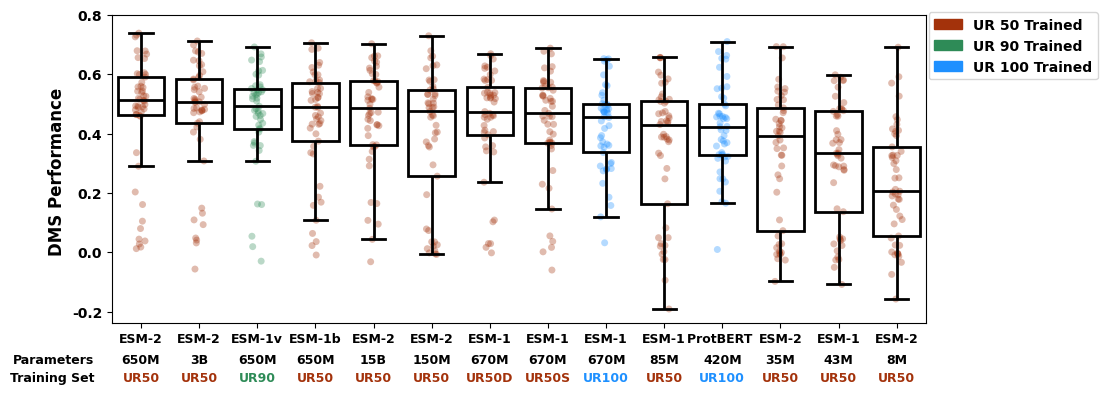

In [25]:
LIMIT_HQ = True

model_to_color = {}
for m in set(display_names.keys()):
    if m in ["esm_1_UR100", "protbert"]:
        model_to_color[m] = ur_100_color
    elif m == "esm_1v":
        model_to_color[m] = ur_90_color
    elif m == "protbert_bfd":
        model_to_color[m] = "black"
    else:
        model_to_color[m] = ur_50_color
        
        
corr_df_plot = corr_df.loc[
    (corr_df.index.isin(representative_experiments)) 
]


if LIMIT_HQ:
    corr_df_plot = corr_df_plot.loc[
        (corr_df_plot.index.isin(representative_experiments)) &
        (corr_df_plot.index.isin(hq_experiments))  
    ]
    

corr_df_plot = corr_df_plot.drop(columns = "protbert_bfd")

model_to_median = {}
model_to_ci = {}
for c in corr_df_plot.columns:
    model_to_median[c] = np.median(corr_df_plot[c])
    model_to_ci[c] = mean_confidence_interval(corr_df_plot[c])
    
model_to_median = sort_dict_by_value(model_to_median, reverse = True)
model_to_dataset_string = dict(zip(model_info["model_string"], model_info["dataset_string"]))
model_to_params_string = dict(zip(model_info["model_string"], model_info["params_string"]))
model_to_base_string = dict(zip(model_info["model_string"], model_info["base_string"]))

x = []
data = []
x_ticklabels = []

my_pal = []

dataset_str_list = []
params_str_list = []

for i, (m_name, mean_val) in enumerate(model_to_median.items()):
    x.append(i)
    label_str = (
        model_to_base_string[m_name]
    )
    params_str_list.append(model_to_params_string[m_name] )
    dataset_str_list.append(model_to_dataset_string[m_name].replace("UR", "UR ").replace("-", ""))
    x_ticklabels.append(label_str)
    data.append(corr_df_plot[m_name].values)
    my_pal.append(model_to_color[m_name])


fig, ax = plt.subplots(figsize = (10.5,4))

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.33,
    palette = my_pal
)





ax.set_ylabel("DMS Performance ", fontsize = 12, fontweight = "bold")
ax.set_xticks(x)
ax.set_xticklabels(
    x_ticklabels, 
    fontsize = 9,
    fontweight = "bold"
)

y_ticks = [-0.2,0.0,0.2,0.4,0.6,0.8]
# y_ticks = [-0.2,0.0,0.2,0.4,0.6,0.8]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontweight = "bold")

if LIMIT_HQ:
    
    ax.set_title("DMS Experiments Limited to HQ_CUTOFF = " + str(HQ_CUTOFF))
    
else:
    
    ax.set_title("DMS Experiments NO HQ LIMIT ")

ax.set_title("")
num_models = len(corr_df_plot.columns)
  
ax.text(-0.8, -0.34, "Parameters", horizontalalignment = "right", fontsize = 9, fontweight = "bold", verticalalignment = "top")
ax.text(-0.8, -0.4, "Training Set", horizontalalignment = "right", fontsize = 9,  verticalalignment = "top", fontweight = "bold")

for i, (m_name, _) in enumerate(model_to_median.items()):
    ax.text(i, -0.34, params_str_list[i],  horizontalalignment = "center", fontsize = 9,  verticalalignment = "top", fontweight = "bold")

    ax.text(i, -0.4, dataset_str_list[i].replace(" ", ""), color = model_to_color[m_name], horizontalalignment = "center", fontsize = 9,  verticalalignment = "top", fontweight = "bold")


red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')

ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.72,0.53,0.5,0.5), prop = {"weight" : "bold"})


if SAVE_FIGS:
    if LIMIT_HQ:
        save_figure(fig, "stripplots_14_models_DMS_score_hq_experiments")
    else:
        save_figure(fig, "stripplots_14_models_DMS_score_all_experiments_non_limited")
        
    
save_figure(fig, "DMS_performance_boxplot", root_path = figure_path_2)


/tmp/ipykernel_125232/2470779379.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
/tmp/ipykernel_125232/2470779379.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
/tmp/ipykernel_125232/2470779379.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

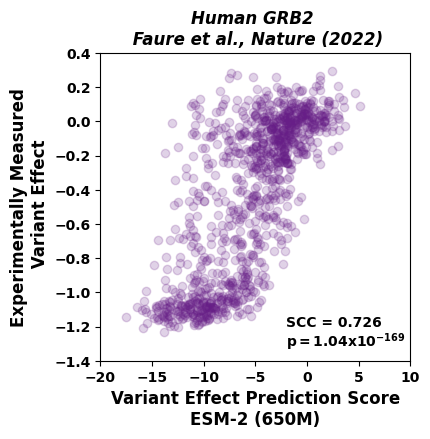

In [26]:

protein_gym_path = llm_review_path + "data/ProteinGym_substitutions/"

exp_name = "GRB2_HUMAN_Faure_2021"

dms_df = pd.read_csv(protein_gym_path + exp_name + ".csv")
# getting only single nt subs 
dms_df = dms_df.loc[~dms_df["mutant"].str.contains(":")]
dms_df["ref"] = dms_df["mutant"].apply(lambda x : x[0])
dms_df["alt"] = dms_df["mutant"].apply(lambda x : x[-1])
dms_df["pos"] = dms_df["mutant"].apply(lambda x : int(x[1:-1])) 

masked_df = pd.read_csv("/Genomics/singhlab/LLM_review/masked_results/protein_gym/esm_2_650M/GRB2_HUMAN.csv.gz")
masked_df = augment_masked_df_with_site_entropy(masked_df)

dms_preds = {}
for p, sub_df in masked_df.groupby("aa_pos"):
    dms_preds[p] = dict(zip(sub_df["token_str"].values, sub_df["adj_score"].values))


# model_to_dms_predictions[model_name][dms_id] = dms_preds

site_to_entropy = dict(zip(masked_df["aa_pos"].values, masked_df["site_entropy"].values))

variant_to_model_score = dict(zip(masked_df.index.values, masked_df['s1'].values))

dms_variants = dms_df.loc[dms_df["mutant"].isin(list(variant_to_model_score.keys()))]
dms_variants = dms_variants.loc[dms_variants["ref"] != dms_variants["alt"]]

x = []
y = []
for index, row in dms_variants.iterrows():
    y.append(row["DMS_score"])
    x.append(variant_to_model_score[row["mutant"]])

corr, p = scipy.stats.spearmanr(x,y)

fig, ax = plt.subplots(figsize = (4,4))

ax.scatter(x,y,color = "#671e87", alpha = 0.2)
# ax.set_xticks([0,1,2,3,4,4.3])
# ax.set_yticks([0,1,2,3,4,4.3])
# ax.set_xticklabels(["0","1","2","3","4",""])
# ax.set_yticklabels(["0","1","2","3","4",""])
ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())

ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

ax.set_xlabel(r"Variant Effect Prediction Score" + "\nESM-2 (650M)", fontsize = 12, fontweight = "bold")

ax.set_ylabel("Experimentally Measured\n Variant Effect", fontsize = 12, fontweight = "bold")
ax.set_title("Human GRB2 \n Faure et al., Nature (2022)", fontsize = 12, fontweight = "bold", fontstyle='italic')

ax.text(-2, -1.2, r"SCC = " + str(round(corr, 3)), fontsize = 10,fontweight = "bold")
ax.text(-2., -1.32, r"$\mathbf{p=" + format_p(p) + "}$", fontweight = "bold", fontsize = 10)

    
save_figure(fig, "DMS_correlation_Faure_GRB2", root_path = figure_path_2)


In [27]:
len(x), len(y)

(1034, 1034)

In [28]:
corr_entropy_df = pd.read_csv("corr_entropy_df.csv", index_col  = 0)

In [29]:

protein_gym = pd.read_csv(llm_review_path + "data/ProteinGym_reference_file_substitutions.csv")
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']

def compute_alignment_counts(dms_id_to_valid_hsps, use_pseudocount =True):
    reg_aa_set = set(regular_aas)

    exp_to_aligned_counts = {}

    for i4, (rep, hsps) in enumerate(dms_id_to_valid_hsps.items()):
        reference_seq = protein_gym.loc[protein_gym["DMS_id"] == rep].iloc[0]["target_seq"]
        positional_counts = {}
        for i, aa in enumerate(reference_seq):
            if use_pseudocount:
                positional_counts[i + 1] = {reg_aa : 1 for reg_aa in regular_aas}
            else:
                positional_counts[i + 1] = {reg_aa : 0 for reg_aa in regular_aas}

        for i5, hsp in hsps.iterrows():
            qseq = hsp["qseq"]
            hseq = hsp["hseq"]
            query_from = hsp["query_from"]
            
            pos = query_from - 1
            assert len(qseq) == len(hseq)
            for aa, aln_aa in zip(qseq, hseq):
                if aa != "-":
                    assert aa == reference_seq[pos] # 0 indexed 
                    if aln_aa != "-" and aln_aa in reg_aa_set:
                        positional_counts[pos + 1][aln_aa] += 1 # 1 indexed 
                    pos += 1
            
        exp_to_aligned_counts[rep] = positional_counts
    
    return exp_to_aligned_counts


def get_aln_DMS_scores(exp_to_aligned_counts, return_x_y = False):
    protein_gym_path =  "/Genomics/singhlab/LLM_review/data/ProteinGym_substitutions/"
    exp_to_custom_aln_score = {}
    exp_to_x_y = {}

    for rep, alignment_counts in exp_to_aligned_counts.items():
        row = protein_gym.loc[protein_gym["DMS_id"] == rep].iloc[0]
        ref_seq = row["target_seq"]
        
        filename = row["DMS_filename"]
        filepath = protein_gym_path + filename

        dms_id = row["DMS_id"]
        
        aln_variant_score = {}
        
        for i , ref_aa in enumerate(ref_seq):
            positional_counts = alignment_counts[i+1]
            count_sum = np.sum(list(positional_counts.values()))
            
            ref_prob = positional_counts[ref_aa] / count_sum
            
            for k, v in positional_counts.items():
                alt_prob = v / count_sum
                s1_score = np.log(alt_prob / ref_prob)
                
                variant_name = ref_aa + str(i+1) + k
                aln_variant_score[variant_name] = s1_score
                
        dms_df = pd.read_csv(filepath)
        dms_df = dms_df.loc[~dms_df["mutant"].str.contains(":")]
        dms_df["ref"] = dms_df["mutant"].apply(lambda x : x[0])
        dms_df["alt"] = dms_df["mutant"].apply(lambda x : x[-1])
        dms_df["pos"] = dms_df["mutant"].apply(lambda x : int(x[1:-1])) 
        dms_df = dms_df.loc[dms_df["ref"] != dms_df["alt"]] 
        dms_df = dms_df.loc[dms_df["mutant"].isin(list(aln_variant_score.keys()))] # removes indels 
        
        x = []
        y = []
        
        
        
        for _, row in dms_df.iterrows():
            x.append(aln_variant_score[row["mutant"]])
            y.append(row["DMS_score"])
            
        corr, _ = scipy.stats.spearmanr(x,y)
        exp_to_custom_aln_score[dms_id] = corr
        exp_to_x_y[dms_id] = {"aln_score" : x, "dms_score" : y}
    
    return exp_to_custom_aln_score, exp_to_x_y



In [30]:
import copy 

In [31]:
hsp_set = all_hsp_dfs["UR50"]

cleaned_hsp_set = {}

for k, dfv in hsp_set.items():
    cleaned_hsp_set[k] = dfv.loc[
        (dfv["percent_identity"] >= PCT_IDENT) & 
        (dfv["alignment_frac"] >= ALN_FRAC) & 
        (dfv["percent_gaps"] <= GAP_PCT) &
        (dfv["evalue"] <= 1e-5)
    ]

exp_to_aligned_counts = compute_alignment_counts(cleaned_hsp_set)
ur50_aln_counts = copy.deepcopy(exp_to_aligned_counts)
aln_dms_scores, aln_x_y = get_aln_DMS_scores(exp_to_aligned_counts, return_x_y = True)

res_lst = []

ur50_aln_scores = copy.deepcopy(aln_dms_scores)
for k,v in aln_dms_scores.items():
#     print(k,v)
    if k in representative_experiments:
        res_lst.append(v)
        
print(round(np.mean(res_lst), 3))
print(round(np.median(res_lst), 3))

# pickle_obj(ur50_aln_counts, "/Genomics/singhlab/LLM_review/data/alignment_aa_counts/ur_50_aln_counts_w_pseudocount.pkl")

0.398
0.427


In [32]:
hsp_set = all_hsp_dfs["UR90"]

cleaned_hsp_set = {}

for k, dfv in hsp_set.items():
    cleaned_hsp_set[k] = dfv.loc[
        (dfv["percent_identity"] >= PCT_IDENT) & 
        (dfv["alignment_frac"] >= ALN_FRAC) & 
        (dfv["percent_gaps"] <= GAP_PCT) &
        (dfv["evalue"] <= 1e-5)
    ]

exp_to_aligned_counts = compute_alignment_counts(cleaned_hsp_set)
ur90_aln_counts = copy.deepcopy(exp_to_aligned_counts)

aln_dms_scores, aln_x_y = get_aln_DMS_scores(exp_to_aligned_counts)
ur90_aln_scores = copy.deepcopy(aln_dms_scores)

res_lst = []
for k,v in aln_dms_scores.items():
#     print(k,v)
    if k in representative_experiments:
        res_lst.append(v)
        
print(round(np.mean(res_lst), 3))
print(round(np.median(res_lst), 3))


0.398
0.426


In [33]:
hsp_set = all_hsp_dfs["UR100"]

cleaned_hsp_set = {}

for k, dfv in hsp_set.items():
    cleaned_hsp_set[k] = dfv.loc[
        (dfv["percent_identity"] >= PCT_IDENT) & 
        (dfv["alignment_frac"] >= ALN_FRAC) & 
        (dfv["percent_gaps"] <= GAP_PCT)&
        (dfv["evalue"] <= 1e-5)
    ]

exp_to_aligned_counts = compute_alignment_counts(cleaned_hsp_set)

ur100_aln_counts = copy.deepcopy(exp_to_aligned_counts)
aln_dms_scores, aln_x_y = get_aln_DMS_scores(exp_to_aligned_counts)


ur100_aln_scores = copy.deepcopy(aln_dms_scores)

res_lst = []
for k,v in aln_dms_scores.items():
#     print(k,v)
    if k in representative_experiments:
        res_lst.append(v)
        
print(round(np.mean(res_lst), 3))
print(round(np.median(res_lst), 3))


0.403
0.418


(0.46029569102018825, 0.401310743402652, 0.5192806386377246)
KstestResult(statistic=0.22448979591836735, pvalue=0.16995747466707573)
p1 0.06248542836759796
###########################
(0.45818287717176065, 0.430411760341878, 0.4859539940016433)
(0.4614506350245992, 0.4151550506995333, 0.5077462193496651)
KstestResult(statistic=0.20408163265306123, pvalue=0.2611068851719254)
MannwhitneyuResult(statistic=1041.0, pvalue=0.2585906606803)
p1 0.18755326798898508
###########################
(0.45886614412505183, 0.4325287852488111, 0.48520350300129256)
(0.42157835997776866, 0.38082381374533913, 0.4623329062101982)
KstestResult(statistic=0.22448979591836735, pvalue=0.16995747466707573)
MannwhitneyuResult(statistic=1383.0, pvalue=0.19595977222557082)
p3 0.17132508427659587


/tmp/ipykernel_125232/1236637277.py:177: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((x[0], y_pos), x[1] - x[0], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
/tmp/ipykernel_125232/1236637277.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((x[2], y_pos), x[3] - x[2], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
/tmp/ipykernel_125232/1236637277.py:183: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((x[4], y_pos), x[5] - x[4], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')


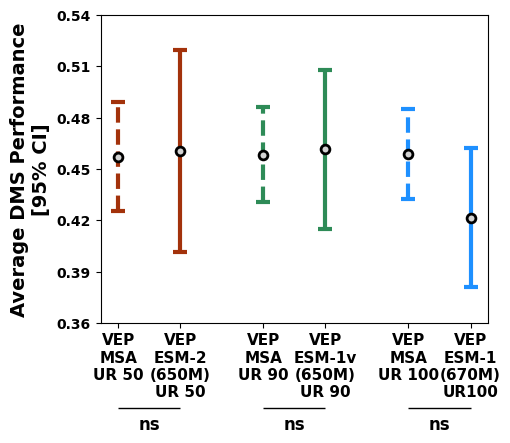

In [34]:
hq_df = corr_df.loc[corr_df.index.isin(representative_experiments) & corr_df.index.isin(hq_experiments)]

aln_score_tracker = {}

res_lst = []

mean_vals = []
error_sizes = []
x = []

for k,v in ur50_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        res_lst.append(v)
        

x_counter = 0 
mci = mean_confidence_interval(res_lst)
x.append(x_counter)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])

mci = mean_confidence_interval(hq_df["esm_2_650M"])
x.append(x_counter + 0.6)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])

print(mean_confidence_interval(hq_df["esm_2_650M"]))
print(scipy.stats.ks_2samp(res_lst, hq_df["esm_2_650M"]))




m50= "esm_2_650M"

x1 = []
x2 = []

for k,v in ur50_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m50])

p_1 = scipy.stats.wilcoxon(x1,x2)[1]


print("p1", p_1)
print("###########################")    

x_counter += 1.4
res_lst = []
for k,v in ur90_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        res_lst.append(v) 
        
        
mci = mean_confidence_interval(res_lst)
x.append(x_counter)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])

mci = mean_confidence_interval(hq_df["esm_1v"])
x.append(x_counter + 0.6)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])
        
print(mean_confidence_interval(res_lst))
print(mean_confidence_interval(hq_df["esm_1v"]))
print(scipy.stats.ks_2samp(res_lst, hq_df["esm_1v"]))
print(scipy.stats.mannwhitneyu(res_lst, hq_df["esm_1v"]))

m90= "esm_1v"

x1 = []
x2 = []

for k,v in ur90_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m90])

p_2 = scipy.stats.wilcoxon(x1,x2)[1]

print("p1", p_2)

print("###########################")  
x_counter += 1.4
res_lst = []
for k,v in ur100_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        res_lst.append(v) 
     

mci = mean_confidence_interval(res_lst)
x.append(x_counter)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])

mci = mean_confidence_interval(hq_df["esm_1_UR100"])
x.append(x_counter + 0.6)
mean_vals.append(mci[0])
error_sizes.append([mci[0] - mci[1], mci[2] - mci[0]])
        
    
print(mean_confidence_interval(res_lst))
print(mean_confidence_interval(hq_df["esm_1_UR100"]))
print(scipy.stats.ks_2samp(res_lst, hq_df["esm_1_UR100"]))
print(scipy.stats.mannwhitneyu(res_lst, hq_df["esm_1_UR100"]))

m100= "esm_1_UR100"

x1 = []
x2 = []

for k,v in ur100_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m100])

p_3 = scipy.stats.wilcoxon(x1, x2)[1]
print("p3", p_3)

fig, ax = plt.subplots(figsize = (5, 4))


groups = [[0,2], [2,4], [4,6]]
c_list = [ur_50_color, ur_90_color, ur_100_color]
for c, g in zip(c_list,groups):
    
    e1 = ax.errorbar(
        x[g[0]:g[1]], 
        mean_vals[g[0]:g[1]], 
        yerr = np.transpose(error_sizes[g[0]:g[1]]), 
        color = c, 
        fmt = ".",
        capsize = 5,
        linewidth = 3,
        zorder = 1
    )
    
    
    e1[-1][0].set_linestyle(['--','-']*3)
    caps = e1[1]
    
    for cap in caps:
        cap.set_markeredgewidth(3)


    ax.scatter(
        x[g[0]:g[1]], 
        mean_vals[g[0]:g[1]], 
        color = "lightgray", 
        edgecolor = "black",
        linewidth=2,
        s = 40,
        zorder = 100
    )
    
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "VEP\nMSA" + "\nUR 50",
            r"VEP" + "\nESM-2\n(650M)\nUR 50",
            "VEP\nMSA" + "\nUR 90",
            r"VEP" + "\nESM-1v\n(650M)\nUR 90",
            "VEP\nMSA" + "\nUR 100",
            r"VEP" + "\nESM-1\n(670M)\nUR100",
            
        ],
        fontsize = 11,
        fontweight = "bold"
    )
    
    
y_pos = 0.31
    
rect = mpatches.Rectangle((x[0], y_pos), x[1] - x[0], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )

rect = mpatches.Rectangle((x[2], y_pos), x[3] - x[2], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )

rect = mpatches.Rectangle((x[4], y_pos), x[5] - x[4], 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )


ax.text((x[1] - x[0]) / 2, y_pos - 0.012, p_val_to_stars(p_1),fontweight = "bold", fontsize = 12, horizontalalignment ="center" )

ax.text(x[2] + (x[3] - x[2]) / 2, y_pos - 0.012, p_val_to_stars(p_2),fontweight = "bold", fontsize = 12, horizontalalignment ="center" )

ax.text(x[4] + (x[5] - x[4]) / 2, y_pos - 0.012, p_val_to_stars(p_3),fontweight = "bold", fontsize = 12, horizontalalignment ="center" )


ax.set_yticks(list(np.arange(0.36,0.54,0.03)))
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylabel("Average DMS Performance\n[95% CI]", fontsize = 14, fontweight = "bold")

if SAVE_FIGS:
    save_figure(fig, "alignment_derived_score_errorplot_vs_model")
    
save_figure(fig, "DMS_alignment_vs_models", root_path=figure_path_2)

In [35]:

m50= "esm_2_650M"

x1 = []
x2 = []

for k,v in ur50_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m50])

print(scipy.stats.wilcoxon(x1,x2))


m90= "esm_1v"

x1 = []
x2 = []

for k,v in ur90_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m90])

print(scipy.stats.wilcoxon(x1,x2))

m100= "esm_1_UR100"

x1 = []
x2 = []

for k,v in ur100_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        x1.append(v)
        x2.append(corr_df.loc[k][m100])

print(scipy.stats.wilcoxon(x1, x2))

np.mean(x1), np.mean(x2)

WilcoxonResult(statistic=425.0, pvalue=0.06248542836759796)
WilcoxonResult(statistic=479.0, pvalue=0.18755326798898508)
WilcoxonResult(statistic=474.0, pvalue=0.17132508427659587)


(0.45886614412505183, 0.42157835997776855)

In [36]:
ent_path = llm_review_path + "high_res_figures/entropy_figure/"

In [37]:

db_dfs = all_hsp_dfs["UR50"]

hom_dict_1 = {}

for k, dfc in db_dfs.items():
   
    dfc_2 = dfc.loc[
        (dfc["percent_identity"] >= PCT_IDENT) & 
        (dfc["alignment_frac"] >= ALN_FRAC) & 
        (dfc["percent_gaps"] <= GAP_PCT)
    ]
    
    if k in representative_experiments:
        hom_dict_1[k] = len(dfc_2)
        
model_1 = "esm_2_15B"
model_2 = "esm_2_150M"

all_hom_vals = list(hom_dict_1.values())
median_val = np.median(all_hom_vals)


/tmp/ipykernel_125232/2904329378.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


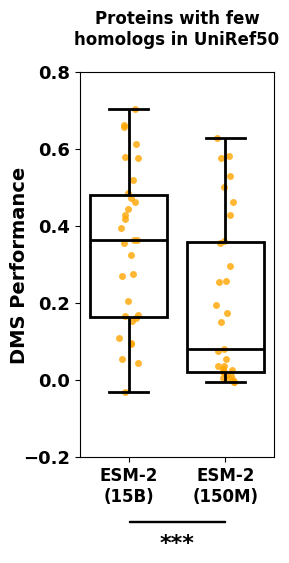

In [43]:
y1 = []
y2 = []

for k, v in hom_dict_1.items():
    m1_v = corr_df[model_1][k]
    m2_v = corr_df[model_2][k]
    
    if v < median_val:
        y1.append(m1_v)
        y2.append(m2_v)

fig, ax = plt.subplots(figsize = (2.5, 5))

data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.8,
    color = "orange"
)

ax.set_yticks(list(np.arange(-0.2,0.9,0.2)))
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold")
ax.set_xticklabels(
    [display_names[model_1].replace(" ", "\n").replace("ESM2", "ESM-2"), display_names[model_2].replace(" ", "\n").replace("ESM2", "ESM-2")],
    fontsize = 12,
    fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)



st, p = scipy.stats.wilcoxon(y1, y2, alternative = "greater")

# ax.text(0.5, -0.29, "MWU $\mathbf{p = " + format_p(p) +  "}$",fontweight = "bold", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 16, transform = ax.transAxes, fontweight = "bold", horizontalalignment = "center")

ax.set_title("Proteins with few\nhomologs in UniRef50", fontsize = 12, y = 1.05, fontweight = "bold")
ax.set_ylabel("DMS Performance", fontsize = 14, labelpad = -4, fontweight = "bold")
# ax.set_yticks(list(np.arange(-0.1,0.9,0.1)))


save_figure(fig, "few_homologs_esm_model_comparison_DMS", root_path=figure_path_2)


In [44]:

st, p = scipy.stats.wilcoxon(y1, y2, alternative = "greater")

p

4.328414797782898e-05

/tmp/ipykernel_125232/249009979.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


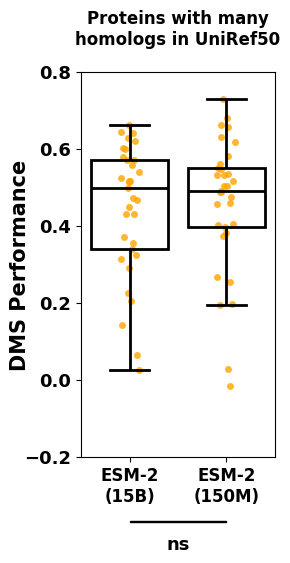

In [45]:
y1 = []
y2 = []

for k, v in hom_dict_1.items():
    m1_v = corr_df[model_1][k]
    m2_v = corr_df[model_2][k]
    
    if v >= median_val:
        y1.append(m1_v)
        y2.append(m2_v)

fig, ax = plt.subplots(figsize = (2.5, 5))

data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.8,
    color = "orange"
)

ax.set_yticks(list(np.arange(-0.2,0.9,0.2)))
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold")
ax.set_xticklabels(
    [display_names[model_1].replace(" ", "\n").replace("ESM2", "ESM-2"), display_names[model_2].replace(" ", "\n").replace("ESM2", "ESM-2")],
    fontsize = 12, 
    fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)


st, p = scipy.stats.wilcoxon(y1,y2, alternative = "greater")

# ax.text(0.5, -0.29, "MWU $p = " + format_p(p) +  "$", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 13, fontweight = "bold", transform = ax.transAxes, horizontalalignment = "center")

ax.set_title("Proteins with many\nhomologs in UniRef50", fontsize = 12, y = 1.05, fontweight = "bold")
ax.set_ylabel("DMS Performance", fontsize = 15, labelpad = -4, fontweight = "bold")

if SAVE_FIGS:
    save_figure(fig, "many_homologs_esm_model_comparison", root_path=ent_path)

save_figure(fig, "many_homologs_esm_model_comparison_DMS", root_path=figure_path_2)

In [46]:
st, p = scipy.stats.wilcoxon(y1, y2, alternative = "greater")

p

0.5837745007593185

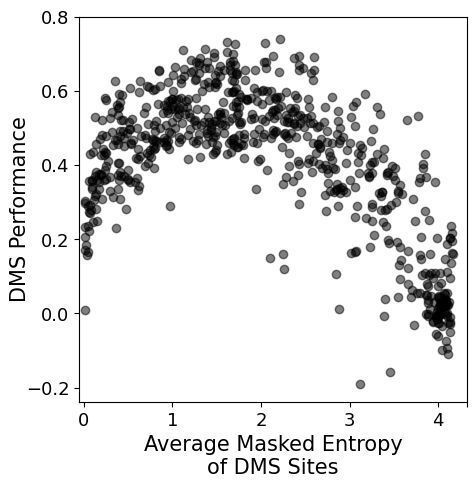

In [81]:
import copy

cdf_2= corr_entropy_df.loc[
    (corr_entropy_df["experiment"].isin(hq_experiments)) &
    (corr_entropy_df["experiment"].isin(representative_experiments)) &
    (corr_entropy_df["model"] != "protbert_bfd") 
]

fig, ax = plt.subplots(figsize = (5,5))
ax.scatter(cdf_2["average_site_entropy"], cdf_2["DMS_correlation"], color = "black", alpha = 0.5)

y_ticks = np.arange(-0.2, 0.81, 0.2)
max_ent = entropy([1/20]*20)
ax.set_yticks(y_ticks)
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13)
ax.set_xticks([0,1,2,3,4,round(max_ent,2)])
ax.set_xticklabels([0,1,2,3,4,""],fontsize = 13)
ax.set_xlim(right = round(max_ent,2) + 0.001, left = -0.05)

ax.set_ylabel("DMS Performance", fontsize = 15, labelpad = -3)
ax.set_xlabel("Average Masked Entropy\n" +  "of DMS Sites", fontsize = 15)

if SAVE_FIGS:
    save_figure(fig, "entropy_v_DMS_score_combined", root_path=ent_path)

# ax.set_title("15 Models", fontsize = 18)


# save_figure(fig, "entropy_vs_dms_performance_arc_all_models", root_path=figure_path_2)

table_d = copy.deepcopy(cdf_2)
table_d["model"] = table_d["model"].apply(lambda x : display_names_a[x])
table_d = table_d.rename(columns = {"experiment" : "Identifier", "model" : "Model", "average_site_entropy" : "Average Site Entropy"})
table_d["Task"] = "DMS"
table_d = table_d[["Task", "Identifier", "Model",  "Average Site Entropy"]]
table_d.to_csv(supp_table_path + "average_site_entropy_DMS.csv", index = False)

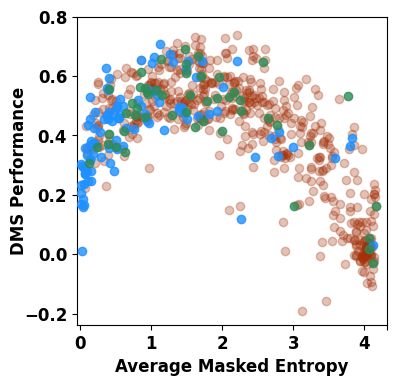

In [84]:
cdf_2 = corr_entropy_df.loc[
    (corr_entropy_df["experiment"].isin(hq_experiments)) &
    (corr_entropy_df["experiment"].isin(representative_experiments)) &
    (corr_entropy_df["model"] != "protbert_bfd") 
]

fig, ax = plt.subplots(figsize = (4,4))


cdf_2a = cdf_2.loc[cdf_2["model"].isin(ur50_models)]
ax.scatter(cdf_2a["average_site_entropy"], cdf_2a["DMS_correlation"], color = ur_50_color, alpha = 0.3, zorder = 1)


cdf_2a = cdf_2.loc[cdf_2["model"].isin(ur100_models)]
ax.scatter(cdf_2a["average_site_entropy"], cdf_2a["DMS_correlation"], color = ur_100_color, alpha = 0.8, zorder = 100)

cdf_2a = cdf_2.loc[cdf_2["model"].isin(["esm_1v"])]
ax.scatter(cdf_2a["average_site_entropy"], cdf_2a["DMS_correlation"], color = ur_90_color, alpha = 0.8, zorder = 100)


y_ticks = np.arange(-0.2, 0.81, 0.2)
max_ent = entropy([1/20]*20)
ax.set_yticks(y_ticks)
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 12, fontweight = "bold")
ax.set_xticks([0,1,2,3,4,round(max_ent,2)])
ax.set_xticklabels([0,1,2,3,4,""],fontsize = 12, fontweight = "bold")
ax.set_xlim(right = round(max_ent,2) + 0.001, left = -0.05)

ax.set_ylabel("DMS Performance", fontsize = 12, labelpad = -3, fontweight = "bold")
ax.set_xlabel("Average Masked Entropy", fontsize = 12, fontweight = "bold")

if SAVE_FIGS:
    save_figure(fig, "entropy_v_DMS_score_combined", root_path=ent_path)
#     
# ax.axvline(x = 1.3, color = "black", zorder = 1000, linestyle = "--", lw = 2, label = r"$\gamma^*$")

# ax.legend(loc = "upper right")
# ax.set_title("15 Models", fontsize = 18)

save_figure(fig, "entropy_vs_dms_performance_arc_all_models_with_color", root_path=figure_path_2)

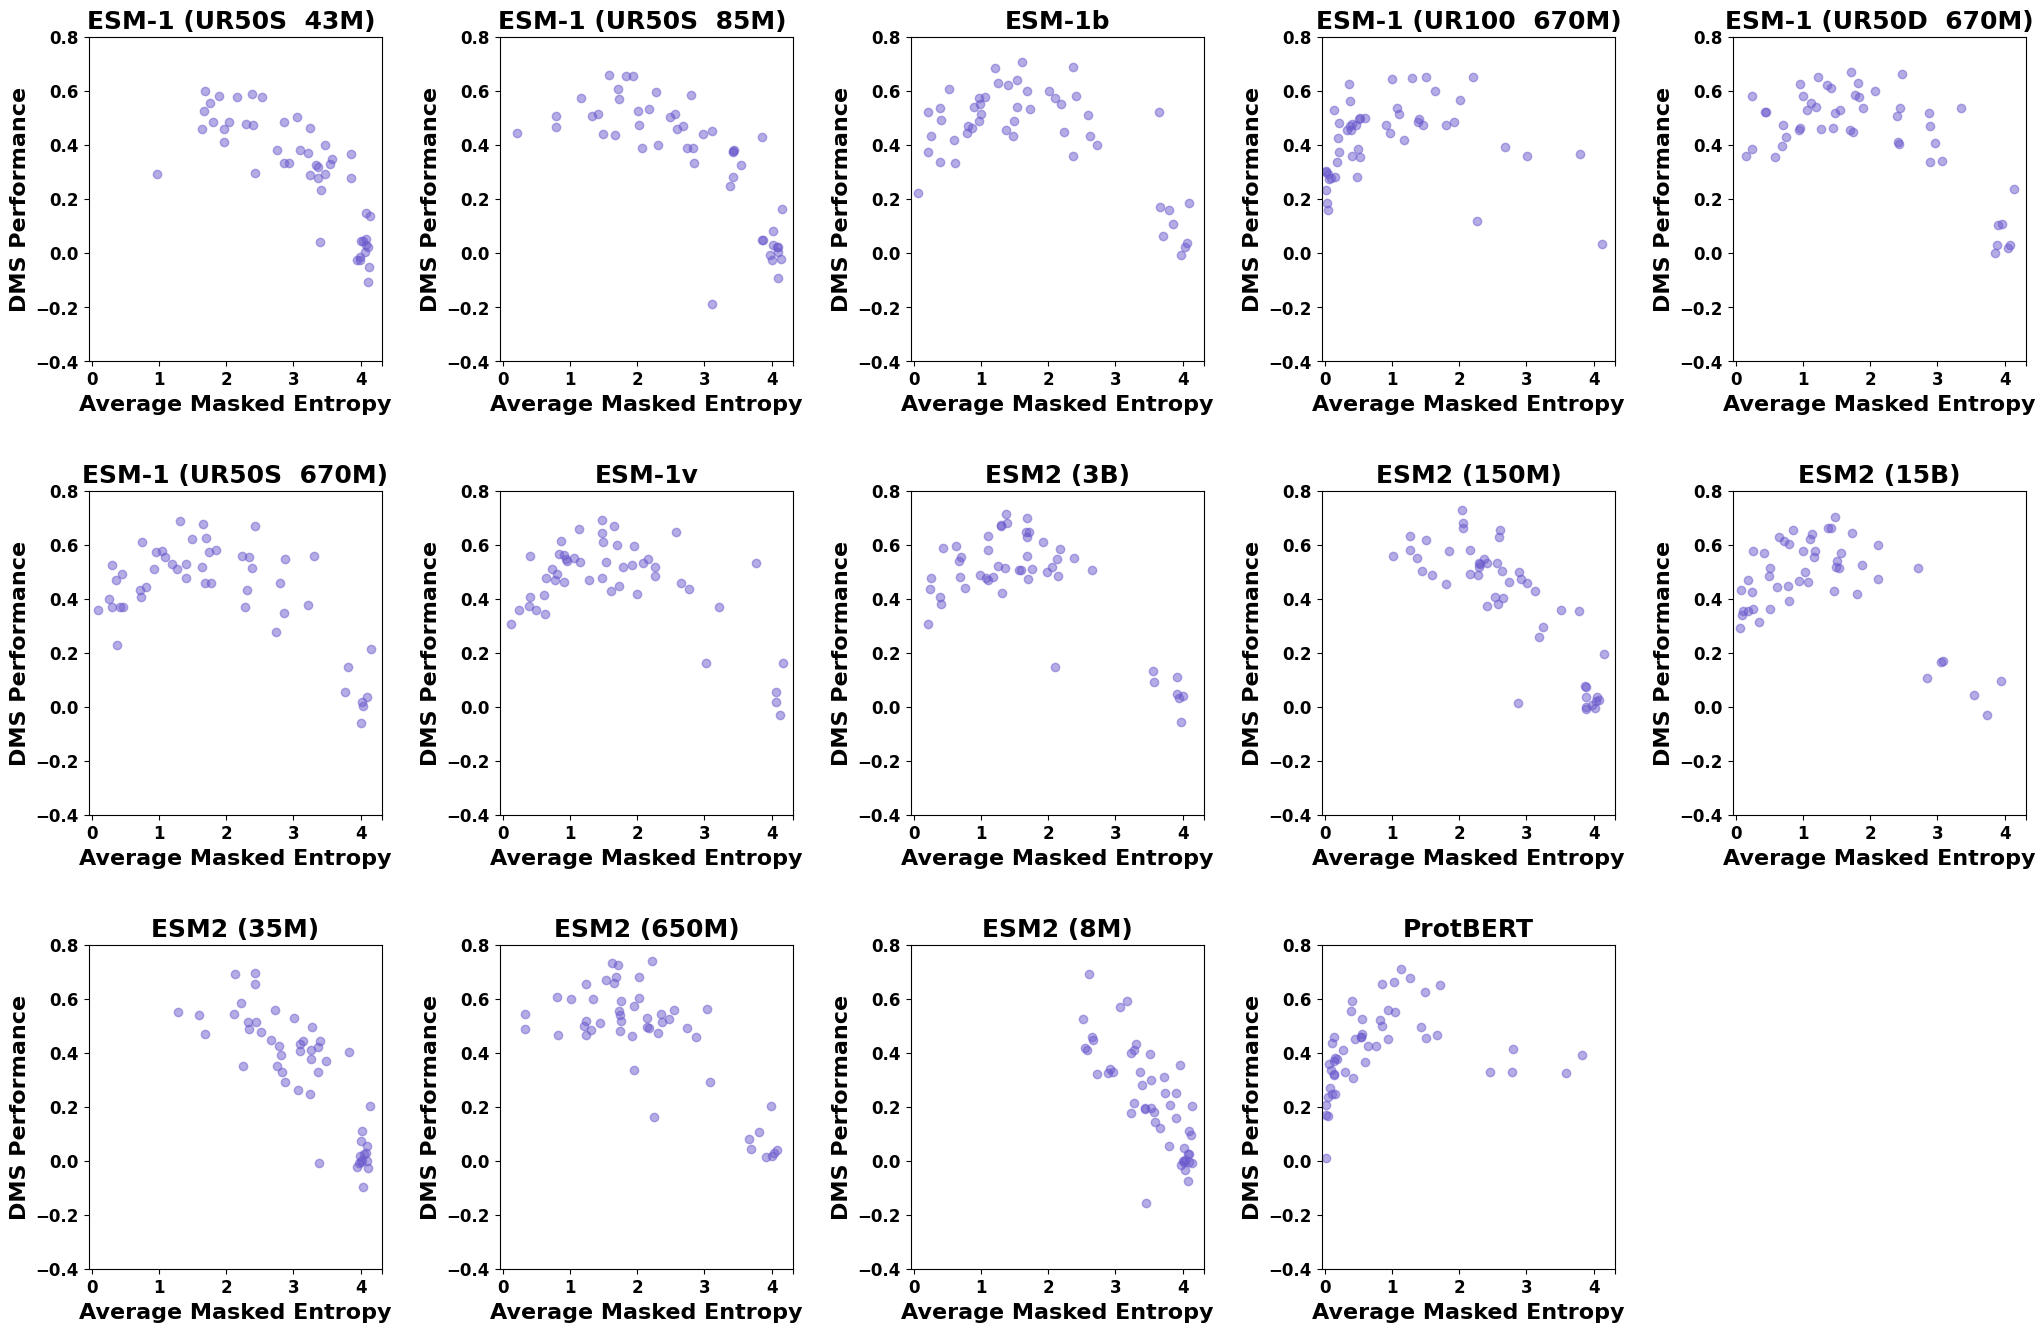

In [89]:
fig, axes = plt.subplots(3,5,figsize = (25, 16))
fig.subplots_adjust(hspace = 0.4, wspace = 0.4)
axes = axes.ravel()
for i, (k, v) in enumerate(display_names.items()):
   
    sub_df  = cdf_2.loc[cdf_2["model"] == k]
    
    ax = axes[i]
    ax.scatter(sub_df["average_site_entropy"], sub_df["DMS_correlation"], alpha = 0.5, color = "slateblue")

    y_ticks = np.arange(-0.4, 0.81, 0.2)
    max_ent = entropy([1/20]*20)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", fontsize = 12)
    ax.set_xticks([0,1,2,3,4,round(max_ent,2)])
    ax.set_xticklabels([0,1,2,3,4,""], fontweight = "bold", fontsize = 12)
    ax.set_xlim(right = round(max_ent,2) + 0.001, left = -0.05)

    ax.set_ylabel("DMS Performance", fontsize = 16, fontweight = "bold")
    ax.set_xlabel("Average Masked Entropy", fontsize = 16, fontweight = "bold")
    ax.set_title(v, fontsize = 18, fontweight = "bold")

fig.delaxes(axes[-1])
if SAVE_FIGS:
    save_figure(fig, "entropy_v_DMS_score_separated",root_path=ent_path)

save_figure(fig, "entropy_vs_dms_performance_arc_individual_models", root_path=figure_path_2)

In [90]:
import copy

exp_to_max_val = {index : np.max(row) for index, row in corr_df.iterrows()}
corr_entropy_df = pd.read_csv("corr_entropy_df.csv")

hq_exps = []
for k,v in exp_to_max_val.items(): 
    if v > 0.4:
        hq_exps.append(k)

set_diff_1 = set(hq_exps).difference(set(representative_experiments))
set_diff_2 = set()
for k,v in exp_to_max_val.items(): 
    if v >= 0.2 and v < 0.4:
        set_diff_2.add(k)
        
        

print(len(set_diff_1), len(set_diff_2))

train_vals = set_diff_2.union(set_diff_1)

print(len(train_vals), set_diff_1, set_diff_2)

train_vals = set_diff_2

selections = corr_entropy_df.loc[corr_entropy_df["experiment"].isin(train_vals)]

point_to_mean = {}
# exp_to_model_choice = {}

c2 = copy.deepcopy(selections)
selections = corr_entropy_df.loc[corr_entropy_df["experiment"].isin(train_vals)]
c2 = c2.loc[c2["model"] != "protbert_bfd"]

print(len(c2.loc[c2["model"] == "esm_2"]))



s0 = set()
set_diff_2

for v in set_diff_2:
    piece = "_".join(v.split("_")[:2])
    s0.add(piece)

s2 = set(hq_exps).intersection(set(representative_experiments)) # 49
s3 = set()
for v in s2:
    piece = "_".join(v.split("_")[:2])
    s3.add(piece)

for i in np.arange(0,4.4,0.1):
    c2["ent_diff"] = c2["average_site_entropy"].apply(lambda x : abs(x - i))
    result_vals = []
    for exp, sub_df in c2.groupby("experiment"):
        piece = "_".join(exp.split("_")[:2])
        if piece in s3: # included in the main experiments 
            print("skipping", exp)
            continue
        sub_df = sub_df.sort_values(by = "ent_diff")
        choice = sub_df.iloc[0]
        result_vals.append(choice["DMS_correlation"])
    
    point_to_mean[i] = np.mean(result_vals)
    

point_to_mean = pd.DataFrame([point_to_mean]).T
point_to_mean = point_to_mean.sort_values(by = 0, ascending = False)
argmax_train_set = point_to_mean.iloc[0].name
print("argmax =", argmax_train_set)


# point_to_mean

13 13
26 {'A0A2Z5U3Z0_9INFA_Doud_2016', 'PTEN_HUMAN_Matreyek_2021', 'VKOR1_HUMAN_Chiasson_activity_2020', 'P53_HUMAN_Giacomelli_WT_Nutlin_2018', 'BLAT_ECOLX_Jacquier_2013', 'CCDB_ECOLI_Adkar_2012', 'P53_HUMAN_Giacomelli_NULL_Etoposide_2018', 'BLAT_ECOLX_Deng_2012', 'BLAT_ECOLX_Firnberg_2014', 'RL401_YEAST_Roscoe_2014', 'RL401_YEAST_Mavor_2016', 'P53_HUMAN_Giacomelli_NULL_Nutlin_2018', 'CP2C9_HUMAN_Amorosi_abundance_2021'} {'GFP_AEQVI_Sarkisyan_2016', 'MK01_HUMAN_Brenan_2016', 'REV_HV1H2_Fernandes_2016', 'ESTA_BACSU_Nutschel_2020', 'I6TAH8_I68A0_Doud_2015', 'TPK1_HUMAN_Weile_2017', 'MSH2_HUMAN_Jia_2020', 'A4D664_9INFA_Soh_CCL141_2019', 'CALM1_HUMAN_Weile_2017', 'SPG1_STRSG_Olson_2014', 'HSP82_YEAST_Flynn_2019', 'SYUA_HUMAN_Newberry_2020', 'ENV_HV1BR_Haddox_2016'}
12
argmax = 1.3


/tmp/ipykernel_2930187/88060442.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([0,1,2,3,4], fontweight = "bold")


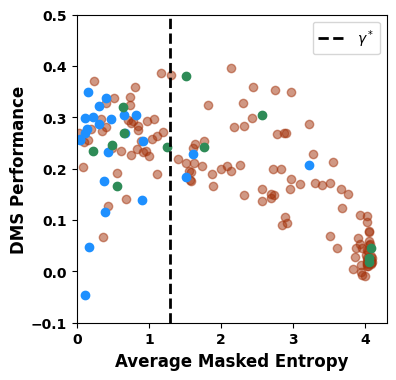

In [92]:

plt.rcParams['text.usetex'] = False

selections = corr_entropy_df.loc[corr_entropy_df["experiment"].isin(train_vals)]

selections = selections.loc[selections["model"] != "protbert_bfd"]

len(set(selections["experiment"].values))



df90 = selections.loc[selections["model"] == "esm_1v"]
df100 = selections.loc[selections["model"].isin(["protbert", "esm_1_UR100"])]
df50 =  selections.loc[~selections["model"].isin(["protbert", "esm_1_UR100", "esm_1v"])]

fig, ax = plt.subplots(figsize = (4,4))

ax.scatter(df50["average_site_entropy"].values, df50["DMS_correlation"].values, color = ur_50_color, alpha = 0.5, zorder = 1)
ax.scatter(df90["average_site_entropy"].values, df90["DMS_correlation"].values, color = ur_90_color, zorder = 10)
ax.scatter(df100["average_site_entropy"].values, df100["DMS_correlation"].values, color = ur_100_color, zorder = 1)



ax.axvline(x = 1.3,    color = "black", linestyle = "--", linewidth = 2, zorder = 100, label = "$\gamma^*$",)

ax.set_ylabel("DMS Performance", fontsize = 12, labelpad = 2, fontweight = "bold")
ax.set_xlabel("Average Masked Entropy", fontsize = 12, fontweight = "bold")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_xticklabels([0,1,2,3,4], fontweight = "bold")
ax.set_xlim(left = 0, right = 4.3)
ax.legend(loc= "upper right", prop = {"weight" : "bold"})


selections.to_csv(supp_table_path + "entropy_optimal_training_experiments.csv")

In [93]:
selections["experiment"].value_counts()

experiment
A4D664_9INFA_Soh_CCL141_2019    14
CALM1_HUMAN_Weile_2017          14
ENV_HV1BR_Haddox_2016           14
ESTA_BACSU_Nutschel_2020        14
GFP_AEQVI_Sarkisyan_2016        14
I6TAH8_I68A0_Doud_2015          14
MK01_HUMAN_Brenan_2016          14
MSH2_HUMAN_Jia_2020             14
REV_HV1H2_Fernandes_2016        14
SPG1_STRSG_Olson_2014           14
SYUA_HUMAN_Newberry_2020        14
TPK1_HUMAN_Weile_2017           14
Name: count, dtype: int64

In [94]:
c3 = corr_entropy_df.loc[
    (corr_entropy_df["experiment"].isin(hq_exps)) &
    (corr_entropy_df["experiment"].isin(representative_experiments)) &
    (corr_entropy_df["model"] != "protbert_bfd") 
]

c3["ent_diff"] = c3["average_site_entropy"].apply(lambda x : abs(x - argmax_train_set))

exp_to_model_selection = {}
exp_to_corr = {}
exp_to_entropy = {}

for exp, sub_df in c3.groupby("experiment"):
    sub_df = sub_df.sort_values(by = "ent_diff")
    choice = sub_df.iloc[0]
    chosen_entropy = choice["average_site_entropy"]
    exp_to_entropy[exp] = chosen_entropy
    exp_to_model_selection[exp] = choice["model"]
    exp_to_corr[exp] = choice["DMS_correlation"]

/tmp/ipykernel_2930187/2105033676.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c3["ent_diff"] = c3["average_site_entropy"].apply(lambda x : abs(x - argmax_train_set))


In [95]:
table_e = []
for k, v in exp_to_corr.items():
    table_e.append([k, "DMS", v, exp_to_model_selection[k], exp_to_entropy[k]])
    
table_e = pd.DataFrame(table_e, columns = ["Identifier", "Task", "Optimal Model Performance", "Optimal Model Choice", "Optimal Model Average Site Entropy"])
table_e["Optimal Model Choice"] = table_e["Optimal Model Choice"].apply(lambda x : display_names_a[x])

table_e.to_csv(supp_table_path + "entropy_optimal_model_choices_DMS.csv")


table_f = []

for k,v in ur50_aln_scores.items():
    if k in representative_experiments and k in hq_experiments:
        table_f.append([k, "DMS", v, ur90_aln_scores[k], ur100_aln_scores[k]])
        
table_f = pd.DataFrame(table_f, columns = ["Identifier", "Task", "UniRef50", "UniRef90", "UniRef100"])
table_f.to_csv(supp_table_path + "aln_scores_all_datasets_DMS.csv", index = False)

/tmp/ipykernel_2930187/2788906156.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_2930187/2788906156.py:77: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(label, fontweight = "bold")


,model,mean,ci_l,ci_u
0,combined,0.535435,0.508831,0.562039
7,esm_1v,0.461451,0.415155,0.507746
12,esm_2_650M,0.460296,0.401311,0.519281
8,esm_2,0.460102,0.404006,0.516199
10,esm_2_15B,0.455910,0.406503,0.505316
5,esm_1_UR50D,0.444072,0.393294,0.494850
3,esm_1b,0.441022,0.387913,0.494131
6,esm_1_UR50S,0.428298,0.375386,0.481211
4,esm_1_UR100,0.421578,0.380824,0.462333
14,protbert,0.416579,0.374495,0.458663


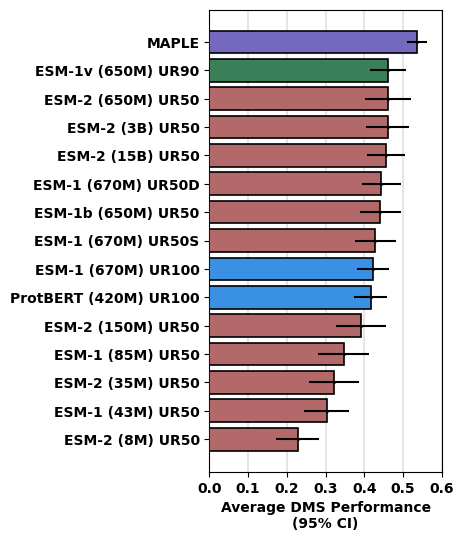

In [100]:
fig, ax = plt.subplots(figsize = (3,6))
model_to_label_1 = {
    'esm_1_43M_UR50S' : "ESM-1 (43M) UR50",
    'esm_1_85M_UR50S': "ESM-1 (85M) UR50",
    'esm_1_UR50S':"ESM-1 (670M) UR50S",
    'esm_1_UR50D':"ESM-1 (670M) UR50D",
    'esm_1_UR100':"ESM-1 (670M) UR100",
    'esm_1b':"ESM-1b (650M) UR50",
    'esm_1v':"ESM-1v (650M) UR90",
    'esm_2_150M':"ESM-2 (150M) UR50",
    'esm_2_15B':"ESM-2 (15B) UR50",
    'esm_2_35M':"ESM-2 (35M) UR50",
    'esm_2':"ESM-2 (3B) UR50",
    'esm_2_650M':"ESM-2 (650M) UR50",
    'esm_2_8M':"ESM-2 (8M) UR50",
    'protbert':"ProtBERT (420M) UR100",
    "combined" : "MAPLE"
}

model_to_color_1 = {'esm_1_43M_UR50S': '#A3320B', 'esm_1_85M_UR50S': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}


data_df = []

m, ci_l, ci_u = mean_confidence_interval(list(exp_to_corr.values()))
data_df.append(["combined", m, ci_l, ci_u])

for col in hq_df.columns:
    if col == "protbert_bfd":
        continue 
    
    lst = hq_df[col].values 
    m, ci_l, ci_u = mean_confidence_interval(lst)
    data_df.append([col, m, ci_l, ci_u])
    
data_df = pd.DataFrame(data_df, columns = ["model", "mean", "ci_l", "ci_u"])

data_df = data_df.sort_values(by = "mean", ascending = False)

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in data_df.iterrows():
    res.append(row["mean"])
    
    label.append(model_to_label_1[row["model"]])
    y.append(c)
    err_vals.append(row["mean"] - row["ci_l"])
    if row["model"] == "combined":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.,0.1,0.2,0.3,0.4,0.5,0.6])
ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_xlim(left = -0.0, right = 0.6)

ax.scatter(res, y, color = "black", s = 1)
ax.errorbar(res, y, xerr = err_vals, fmt = ".", zorder = 1000, markersize = 1, color = "black")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)


ax.set_xlabel("Average DMS Performance\n(95% CI)", fontweight = "bold")
ax.set_yticklabels(label, fontweight = "bold")

data_df

In [108]:
next_model = "esm_1v"

x1 = []
x2 = []

for index, row in table_e.iterrows():
    id_ = row["Identifier"]
    selection = corr_df.loc[id_][next_model]
    x1.append(row["Optimal Model Performance"])
    x2.append(selection)

scipy.stats.wilcoxon(x1,x2,alternative = "greater")

/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


WilcoxonResult(statistic=827.0, pvalue=0.0002383689499418296)

In [109]:
combined_val = data_df.loc[data_df["model"] == "combined"].iloc[0]["mean"]

non_combined = data_df.loc[data_df["model"] != "combined"]
non_combined = non_combined.sort_values(by = "mean", ascending = False)
highest_score = non_combined.iloc[0]["mean"]

pct_increase = (combined_val - highest_score) / highest_score

print("pct increase", pct_increase)

z_val = np.std(non_combined["mean"].values)

print("z increase", (combined_val - highest_score) / z_val)

pct increase 0.1603303245100749
z increase 1.0651532869251779


In [110]:
p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "greater")[1]
p2 = scipy.stats.mannwhitneyu(data[0], data[2], alternative = "greater")[1]
p3 = scipy.stats.mannwhitneyu(data[0], data[3], alternative = "greater")[1]

p1, p2,p3

(0.40730930550776473, 0.23430839377873913, 0.1759830241883547)

14


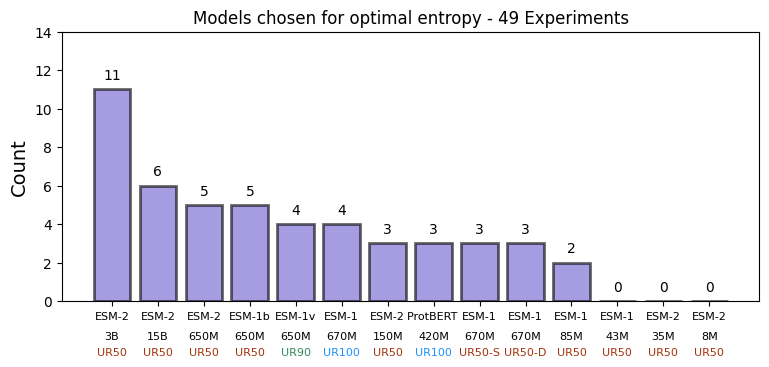

In [111]:
val_results = list(exp_to_model_selection.values())
to_plot = {}
for k in set(val_results):
    to_plot[k] = val_results.count(k)
    
for m in model_info["model_string"].values:
    if m != "protbert_bfd" and m not in to_plot.keys():
        to_plot[m] = 0
        

#     print(k, val_results.count(k))
fig, ax = plt.subplots(figsize = (9,3.5))
to_plot = sort_dict_by_value(to_plot, reverse = True)
labels = list(map(lambda x : model_to_base_string[x],  list(to_plot.keys())))


x = list(np.arange(0, (len(to_plot)), 1.0))

print(len(x))

ax.bar(x, list(to_plot.values()), color = "slateblue", alpha = 0.6, edgecolor = "black", linewidth = 2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize = 8)
ax.bar_label(ax.containers[0], padding = 5)
ax.set_yticks(np.arange(0, 15,2))
ax.set_title("Models chosen for optimal entropy - 49 Experiments")
for i, k in enumerate(to_plot.keys()):
    ax.text(i, -2, model_to_params_string[k], fontsize = 8, horizontalalignment = "center")
    ax.text(i, -2.8,model_to_dataset_string[k], fontsize = 8 , horizontalalignment = "center", color=model_to_color[k] )
    
ax.set_ylabel("Count", fontsize = 14)

if SAVE_FIGS:
    save_figure(fig, "model_choice_histogram", root_path=ent_path)

/tmp/ipykernel_2930187/3330964528.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


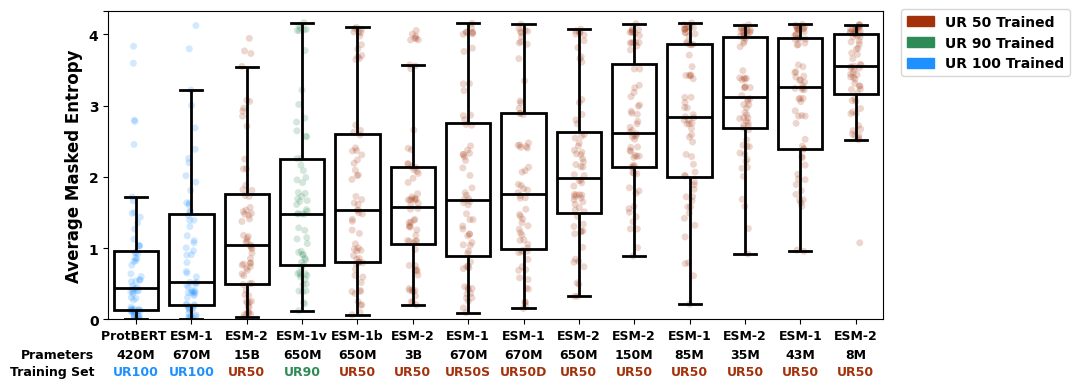

In [147]:
corr_ent = pd.read_csv("corr_entropy_df.csv")
corr_ent = corr_ent.loc[corr_ent["experiment"].isin(representative_experiments)]

m_to_median_entropy = {m : np.median(sub_df["average_site_entropy"]) for (m, sub_df) in corr_ent.groupby(by = "model")}
m_to_median_entropy = sort_dict_by_value(m_to_median_entropy)

x = []
data = []
x_ticklabels = []

my_pal = []

i = 0
for k, v in m_to_median_entropy.items():
    if k == "protbert_bfd":
        continue 
    sub_df = corr_ent.loc[corr_ent["model"] == k]
    x.append(i)
    x_ticklabels.append(model_to_base_string[k])
    data.append(sub_df['average_site_entropy'].values)
    my_pal.append(model_to_color[k])
    i += 1
    
fig, ax = plt.subplots(figsize = (10,4))

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.2,
    color = "lightsteelblue",
    palette = my_pal
)

ax.set_ylabel("Average Masked Entropy", fontsize = 12, fontweight = "bold")
ax.set_xticks(x)
ax.set_xticklabels(
    x_ticklabels, 
    fontsize = 9,
    fontweight = "bold"
)
x_i = 0
for i, k in enumerate(m_to_median_entropy.keys()):
    if k == "protbert_bfd":
        continue 
    ax.text(x_i, -0.55, model_to_params_string[k], fontsize = 9, horizontalalignment = "center", fontweight = "bold")
    ax.text(x_i, -0.78,model_to_dataset_string[k].replace("-", ""), fontsize = 9 , horizontalalignment = "center", color=model_to_color[k] , fontweight = "bold")
    x_i += 1

ax.text(-0.75, -0.55, "Prameters", fontsize = 9, horizontalalignment = "right", fontweight = "bold")
ax.text(-0.75, -0.78, "Training Set", fontsize = 9, horizontalalignment = "right", fontweight = "bold")

ent_ticks= [0,1,2,3,4,4.322]
ent_labels = ["0", "1","2","3","4", ""]
ax.set_yticks(ent_ticks)
ax.set_yticklabels(ent_labels, fontweight = "bold")
ax.set_ylim(bottom = 0, top = 4.322)

red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')

ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.75,0.53,0.5,0.5), prop = {"weight" : "bold"})


if SAVE_FIGS:
    save_figure(fig, "model_entropy_boxplots", root_path=ent_path)
